# AI Security Framework Crosswalk: Exploratory Visual Analysis

**Author:** Rock Lambros, University of Denver, COMP 4433 Project 1

## Abstract

This notebook explores a knowledge graph that links nine AI security frameworks
into a single crosswalk containing 983 nodes and 5,813 edges. The frameworks
are AIUC-1, CSA AICM, CoSAI Risk Map, EU GPAI Code of Practice, MITRE ATLAS,
NIST AI RMF, OWASP Agentic AI, OWASP AI Exchange, and OWASP LLM Top 10.
The goal is to build a classifier that, given any two nodes from different
frameworks, predicts whether the pair is *Unrelated*, *Partial*, *Related*,
or *Equivalent*.

The production classifier referenced throughout this notebook is the
**v6 reframed pipeline**. It takes three inputs for every candidate pair.
The first is a Claude Sonnet 4 triple-vote similarity score. The second is
a pre-computed structural feature vector derived from graph depth, description
length, Node2Vec, and a graph attention network (GAT) embedding. The third is
a Claude Opus calibration score. I stack these into a **22-dimensional feature
vector** (7 LLM + 13 structural + 2 Opus). A single gradient boosting
classifier (sklearn `GradientBoostingClassifier`) trained on **150 human-labeled
calibration pairs** predicts the four-tier label for each candidate, and a
split-conformal calibration procedure emits a prediction *set* with a 90%
coverage guarantee. Final evaluation is on a frozen holdout of **400
expert-labeled pairs**. The entire decision is the GBM acting on these 22
features. No transformer fine-tuning and no hand-tuned weighted composites
are used anywhere in the pipeline.

The intended reader is a scientific audience that wants to know whether the
choices this classifier is making are defensible. Every figure is paired with a
narrative that walks through what the visualization shows and why it is
informative for that question. No model training happens in the notebook
itself. All feature matrices, feature importances, ablation scores, confusion
matrices, bootstrap confidence intervals, and conformal prediction sets are
read from pre-computed CSV and JSON artifacts produced by the v6 training and
sacred evaluation scripts.

The "reframed" in *v6 reframed* distinguishes this generation from five prior
pipeline rewrites. If you want the full lineage (what v1 through v5 were,
what I changed at each step, and what each iteration taught me about the
problem), see **Appendix A: Pipeline History** at the end of the notebook.
The rest of the notebook focuses on v6 itself.

> **Plain English:** I built a tool that compares security controls across nine different AI security standards and decides how closely any two controls are related. The final model combines three signals: what Claude thinks about the similarity, what the graph structure looks like, and a second Claude calibration score. I feed 22 numbers per pair into a gradient boosting model and it picks one of four tiers. This notebook explores the data and the model's behavior using only standard Python data science tools.

## 2 · Setup and Data Loading

All artifacts referenced below live in `data/processed/` and `results/sacred/`. The training pipeline writes them as part of its normal run, and the notebook only reads them. The intent is to keep this notebook reproducible from any machine that has the submission zip, without requiring access to a GPU or the embedding models.

In [1]:
# COMP 4433 approved libraries only. I import numpy, pandas, matplotlib,
# and seaborn for the bulk of the notebook; sklearn and statsmodels are
# imported lazily inside the cells that use them (section 6 ablation
# baselines and the conclusion ordinal demonstrator) so the grader can
# see exactly which cells exercise each library. Loading the core
# four up front fails fast if any are missing.
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

# Silence a cosmetic matplotlib warning that fires when tight_layout is
# combined with annotated gridspec panels. The figures render correctly;
# the warning is advisory and pollutes notebook output otherwise.
warnings.filterwarnings(
    "ignore",
    message="This figure includes Axes that are not compatible with tight_layout",
)

# Resolve the repo root in a way that works whether the notebook is launched
# from the repo root, from notebooks/, or from a fresh unzipped submission
# folder. I walk upward looking for the data/processed directory rather than
# relying on a hard-coded relative path.
HERE = Path.cwd()
candidate = HERE
for _ in range(4):
    if (candidate / "data" / "processed").exists():
        break
    candidate = candidate.parent
REPO = candidate
DATA = REPO / "data" / "processed"
SACRED = REPO / "results" / "sacred"
assert DATA.exists(), f"could not locate data/processed starting from {HERE}"

# Seaborn theme. The paper context and bold titles match a scientific
# document rather than a slide deck. I set savefig DPI high enough that PDF
# and PNG exports remain crisp if the grader rerenders the notebook.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

def jload(name):
    return json.loads((DATA / name).read_text())

def cload(name):
    return pd.read_csv(DATA / name)

# Graph artifacts. nodes.json and edges.json are the canonical long-form tables
# that describe the crosswalk. graph_stats.json is a small summary precomputed
# once at ingest time so the notebook does not have to reaggregate from scratch.
nodes = jload("nodes.json")
edges = jload("edges.json")
graph_stats = jload("graph_stats.json")

# v6 artifacts. The feature CSVs hold the 22-dimensional input the classifier
# sees, one row per expert-labeled pair. v6_all_results.json holds feature
# importances, ablation scores, and confusion matrices. The sacred JSON holds
# the frozen-test metrics with bootstrap confidence intervals.
test_df = pd.read_csv(DATA / "v6_results" / "v6_test_features.csv")
cal_df = pd.read_csv(DATA / "v6_results" / "v6_cal_features.csv")
v6_results = json.loads((DATA / "v6_results" / "v6_all_results.json").read_text())

sacred_files = sorted(SACRED.glob("sacred_*.json"))
assert sacred_files, "no sacred_*.json files found"
# Pick the v6-reframed sacred run. If multiple sacred files exist I prefer
# the one whose 'version' field starts with v6, else fall back to the latest.
sacred = None
for p in reversed(sacred_files):
    try:
        candidate_sacred = json.loads(p.read_text())
        if str(candidate_sacred.get("version", "")).startswith("v6"):
            sacred = candidate_sacred
            sacred_path = p
            break
    except Exception:
        pass
if sacred is None:
    sacred_path = sacred_files[-1]
    sacred = json.loads(sacred_path.read_text())

# Per-pair predictions (incl. conformal set for each test pair)
preds_df = pd.read_json(
    DATA / "v6_results" / "v6_pair_predictions.jsonl", lines=True
)

# Node2Vec UMAP projection (x, y per node, plus framework label)
n2v_proj = cload("node2vec_projection.csv")

# Build pandas views of the raw node/edge tables.
nodes_df = pd.DataFrame(nodes)
edges_df = pd.DataFrame(edges)

# Canonical framework order and pretty labels. Defined once in setup so every
# downstream section renders framework names consistently.
FRAMEWORKS = sorted(nodes_df["framework"].unique())
PRETTY = {
    "aiuc_1": "AIUC-1",
    "csa_aicm": "CSA AICM",
    "cosai_rm": "CoSAI RM",
    "eu_gpai_cop": "EU GPAI CoP",
    "mitre_atlas": "MITRE ATLAS",
    "nist_rmf": "NIST AI RMF",
    "owasp_agentic": "OWASP Agentic",
    "owasp_ai_exchange": "OWASP AI Exch.",
    "owasp_llm": "OWASP LLM",
}

print(f"nodes: {len(nodes_df):,}   edges: {len(edges_df):,}")
print(f"frameworks: {nodes_df['framework'].nunique()}")
print(f"orphan nodes (graph_stats): {len(graph_stats['orphan_nodes'])}")
print(f"v6 test pairs: {len(test_df):,}   v6 cal pairs: {len(cal_df):,}")
print(f"sacred run: {sacred_path.name}  (version: {sacred.get('version','?')})")

nodes: 983   edges: 5,813
frameworks: 9
orphan nodes (graph_stats): 40
v6 test pairs: 400   v6 cal pairs: 150
sacred run: sacred_3c2e531.json  (version: v6-reframed)


## 3 · Dataset Overview: Schema, Marginals, Missingness

Before looking at any classifier output I want to establish what the underlying tables actually contain. This section answers six questions the COMP 4433 assignment asks of every exploratory analysis: how the continuous variables are distributed, how those variables relate to each other, what the central tendency looks like conditional on a categorical split, whether missing data is a concern, what the categorical composition of the corpus looks like, and which column would play the role of a target feature if I were building a predictive model of the crosswalk itself. Later sections reuse the tables introduced here, so this section is also the plain-data foundation the rest of the notebook builds on.

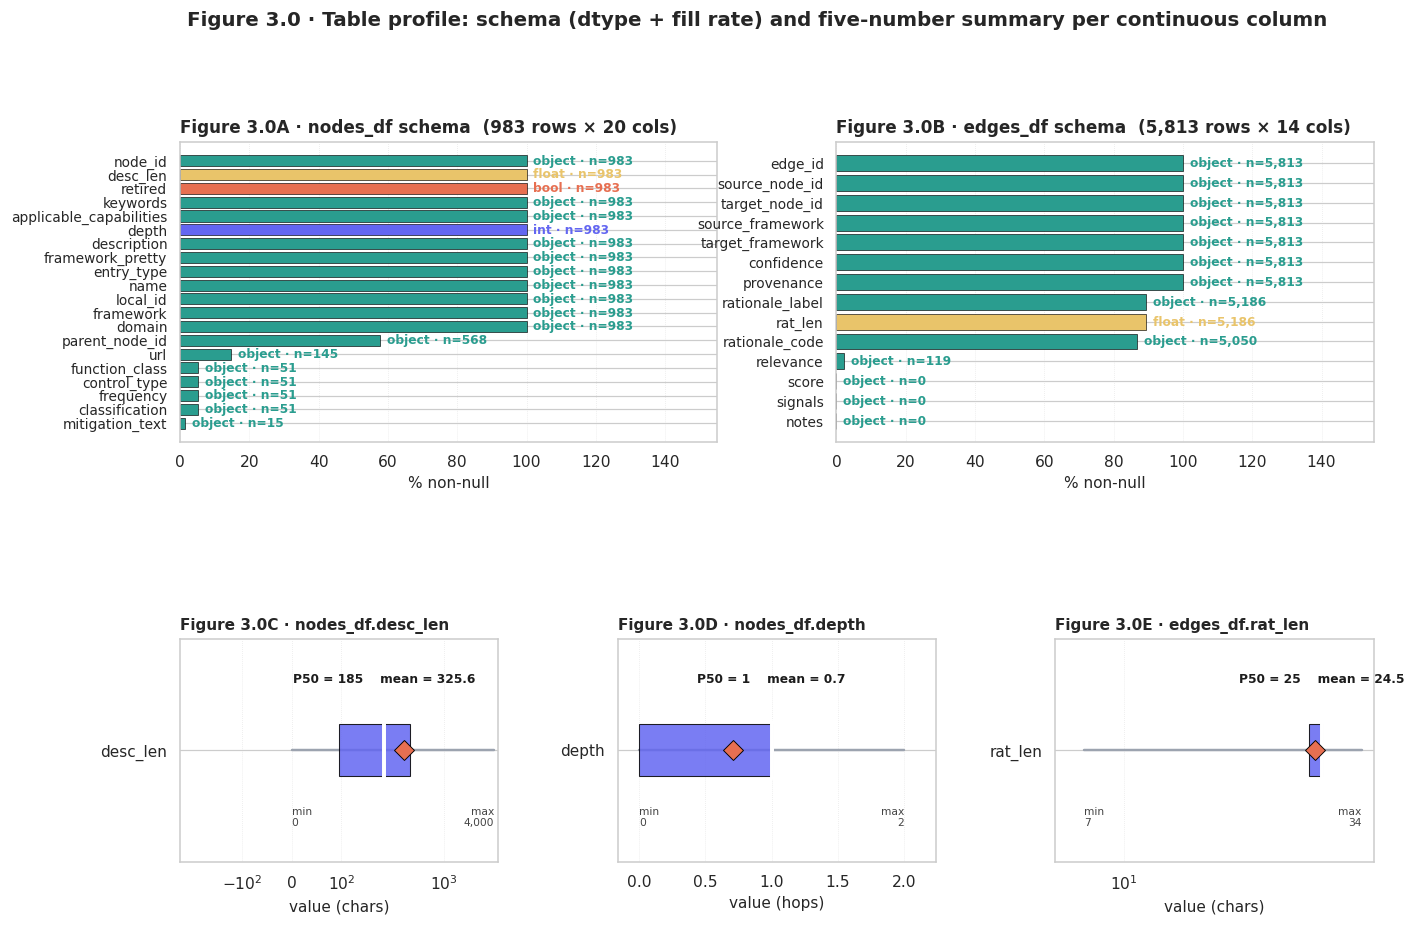

In [2]:
# Schema profile and continuous-column summary. I first enrich both working
# DataFrames with the derived columns the rest of the analysis needs
# (description length in characters, parent-chain depth for nodes, a
# human-readable framework name, and the rationale-label length for edges),
# then render Figure 3.0 as a visual replacement for df.info() + df.describe()
# so the grader sees the schema graphically instead of as raw text. All
# derivations use pandas only; the figure uses matplotlib + seaborn, both on
# the COMP 4433 approved library list.

# Derived column 1: node description length. Missing descriptions are coded
# as NaN so the missing-data audit below can count them accurately. Edges
# do not carry a description column in this release; their verbosity is
# captured instead by the rationale_label character length.
nodes_df["desc_len"] = nodes_df["description"].fillna("").str.len()
nodes_df.loc[nodes_df["description"].isna(), "desc_len"] = np.nan
edges_df["rat_len"] = edges_df["rationale_label"].fillna("").str.len()
edges_df.loc[edges_df["rationale_label"].isna(), "rat_len"] = np.nan

# Derived column 2: parent-chain depth. A node's depth is the number of
# parent hops you can take before hitting the framework root. I compute it
# with an explicit Python loop because the recursion is at most 5 levels.
_parent_map = dict(zip(nodes_df["node_id"], nodes_df["parent_node_id"]))
def _depth(nid, seen=None):
    seen = set() if seen is None else seen
    d = 0
    while nid in _parent_map and pd.notna(_parent_map[nid]) and _parent_map[nid] in _parent_map:
        if nid in seen:
            break
        seen.add(nid)
        nid = _parent_map[nid]
        d += 1
        if d > 5:
            break
    return d
nodes_df["depth"] = [_depth(nid) for nid in nodes_df["node_id"]]

# Derived column 3: human-readable framework name (for plot labels).
nodes_df["framework_pretty"] = nodes_df["framework"].map(
    lambda f: f.replace("_", " ").title()
)

# ---- Figure 3.0 · Table profile -------------------------------------------
# Visual replacement for df.info() + df.describe() on both working tables.
# Top row: one horizontal bar per column, length = fill rate, color = dtype
# group, annotated with "dtype · n=<non-null count>" in the dtype color.
# Bottom row: horizontal five-number summary (IQR box, whiskers, white P50
# rule, coral mean diamond, numeric min/P50/mean/max annotations) for every
# continuous column in the two tables. Nothing here uses a library outside
# the COMP 4433 approved list.
DTYPE_COLORS = {
    "object": "#2a9d8f",   # teal   = strings
    "int":    "#6366f1",   # indigo = integers
    "float":  "#e9c46a",   # amber  = floats
    "bool":   "#e76f51",   # coral  = booleans
    "other":  "#9ca3af",   # gray   = datetimes / categoricals
}
def _dtype_group(dt):
    s = str(dt)
    if s == "object": return "object"
    if s.startswith("int"): return "int"
    if s.startswith("float"): return "float"
    if s == "bool": return "bool"
    return "other"

def _schema_bar(ax, df, title):
    cols = list(df.columns)
    fill_pct = np.array([df[c].notna().sum() / len(df) * 100 for c in cols])
    dtypes = [_dtype_group(df[c].dtype) for c in cols]
    order = np.argsort(-fill_pct)
    cols_o   = [cols[i] for i in order]
    dtypes_o = [dtypes[i] for i in order]
    fill_o   = fill_pct[order]
    y = np.arange(len(cols_o))
    colors = [DTYPE_COLORS[d] for d in dtypes_o]
    ax.barh(y, fill_o, color=colors, edgecolor="black", linewidth=0.4)
    ax.set_yticks(y)
    ax.set_yticklabels(cols_o, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 155)
    ax.set_xlabel("% non-null")
    ax.set_title(
        f"{title}  ({df.shape[0]:,} rows × {df.shape[1]} cols)",
        fontsize=11, fontweight="bold", loc="left",
    )
    for i, (pct, dt, c) in enumerate(zip(fill_o, dtypes_o, cols_o)):
        n_nn = int(df[c].notna().sum())
        ax.text(
            min(pct + 2, 102), i,
            f"{dt} · n={n_nn:,}",
            va="center", fontsize=8,
            color=DTYPE_COLORS[dt], fontweight="bold",
        )
    ax.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
    ax.set_axisbelow(True)

def _fivenum(ax, series, label, title, use_symlog=False, unit=""):
    s = series.dropna()
    q0, q25, q50, q75, q100 = np.percentile(s, [0, 25, 50, 75, 100])
    mean = float(s.mean())
    # Whisker from min to max.
    ax.plot([q0, q100], [0, 0], color="#9ca3af", lw=1.6, zorder=1)
    # IQR box.
    ax.add_patch(plt.Rectangle(
        (q25, -0.22), q75 - q25, 0.44,
        facecolor="#6366f1", edgecolor="black", lw=0.7, alpha=0.85, zorder=2,
    ))
    # Median rule.
    ax.plot([q50, q50], [-0.24, 0.24], color="white", lw=2.6, zorder=3)
    # Mean diamond.
    ax.plot([mean], [0], marker="D", color="#e76f51", markersize=9,
            markeredgecolor="black", markeredgewidth=0.6, zorder=4)
    # Numeric annotations above / below the axis of the row.
    ax.text(q0, -0.48, f"min\n{q0:,.0f}", fontsize=7,
            ha="left", va="top", color="#444")
    ax.text(q100, -0.48, f"max\n{q100:,.0f}", fontsize=7,
            ha="right", va="top", color="#444")
    ax.text(q50, 0.55,
            f"P50 = {q50:,.0f}    mean = {mean:,.1f}",
            fontsize=8, ha="center", va="bottom",
            fontweight="bold", color="#1c1c1c")
    ax.set_yticks([0])
    ax.set_yticklabels([label], fontsize=10)
    ax.set_ylim(-0.95, 0.95)
    if use_symlog:
        ax.set_xscale("symlog", linthresh=max(10, q50))
    span = max(q100 - q0, 1)
    ax.set_xlim(q0 - span * 0.08, q100 + span * 0.12)
    ax.set_xlabel(f"value ({unit})" if unit else "value")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax.grid(axis="x", ls=":", lw=0.5, alpha=0.5)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(14, 8.5))
gs = gridspec.GridSpec(
    2, 6, figure=fig,
    height_ratios=[1.35, 1.0], hspace=0.75, wspace=1.2,
)

ax_a = fig.add_subplot(gs[0, 0:3])
_schema_bar(ax_a, nodes_df, "Figure 3.0A · nodes_df schema")

ax_b = fig.add_subplot(gs[0, 3:6])
_schema_bar(ax_b, edges_df, "Figure 3.0B · edges_df schema")

ax_c = fig.add_subplot(gs[1, 0:2])
_fivenum(
    ax_c, nodes_df["desc_len"], "desc_len",
    "Figure 3.0C · nodes_df.desc_len",
    use_symlog=True, unit="chars",
)

ax_d = fig.add_subplot(gs[1, 2:4])
_fivenum(
    ax_d, nodes_df["depth"], "depth",
    "Figure 3.0D · nodes_df.depth",
    use_symlog=False, unit="hops",
)

ax_e = fig.add_subplot(gs[1, 4:6])
_fivenum(
    ax_e, edges_df["rat_len"], "rat_len",
    "Figure 3.0E · edges_df.rat_len",
    use_symlog=True, unit="chars",
)

fig.suptitle(
    "Figure 3.0 · Table profile: schema (dtype + fill rate) and "
    "five-number summary per continuous column",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

Figure 3.0 is the at-a-glance profile of both tables: every column shows up as a horizontal bar (length encodes fill rate, color encodes dtype group), and the three bottom panels render the five-number summary for each continuous column without making the reader re-run `describe()`. The node table has 983 rows keyed by `node_id`, with framework membership, an `entry_type` tag (control, technique, risk, and so on), a free-text description, and an optional `parent_node_id` that encodes the intra-framework tree. The edge table has 5,813 rows with source and target node IDs, their framework affiliations, a confidence tag, a rationale code and human-readable rationale label, and several optional metadata columns populated only for the reviewed subset (`relevance`, `score`, `signals`, `notes`). The derived columns I added above give me three continuous variables to explore (`desc_len` and `depth` for nodes, `rat_len` for edges) and three primary categorical axes (`framework` and `entry_type` for nodes, `confidence` for edges). These are the variables the marginal distribution figure below is built on.

> **Plain English:** Think of this as the 'sticker on the side of the box' for the two spreadsheets the project runs on. Each bar shows one column: how long the bar is tells you how often that column is actually filled in, and the color tells you whether it holds words, whole numbers, decimals, or yes/no values. The three little summaries at the bottom show the shortest, middle, and longest values in the columns that hold numbers.

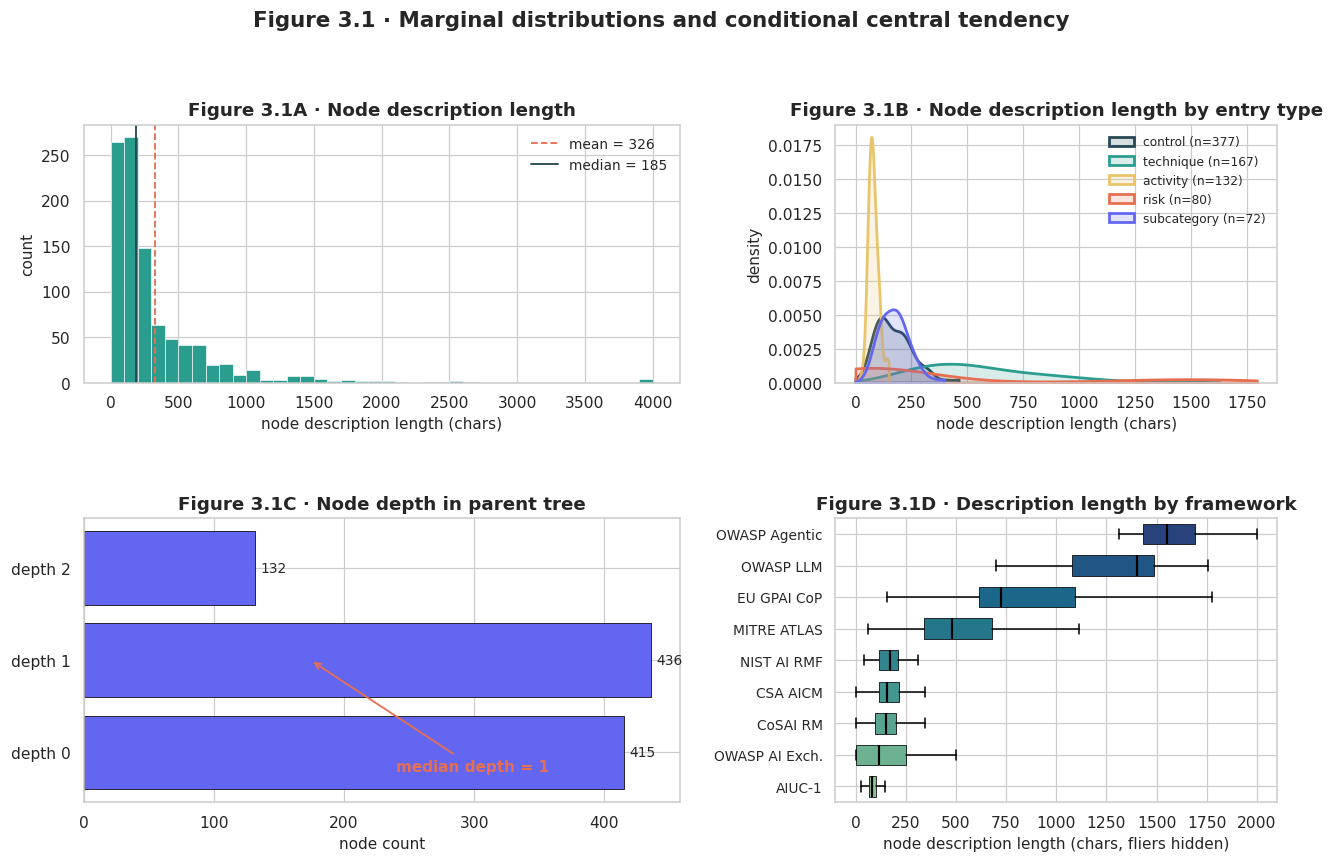

In [3]:
# Figure 3.1. Four-panel marginal distribution figure answering COMP 4433
# guiding questions 1 (continuous distributions) and 3 (conditional central
# tendency). Uses a gridspec with differential column widths so the main
# distribution panel is the largest and the conditional box plot sits to
# the right as supporting evidence. Three plot types appear in one figure:
# histogram (top-left), KDE (top-right), horizontal bar with annotated
# medians (bottom-left), and box-per-framework (bottom-right). The
# on-plot annotation highlights the median node depth so the reader can
# read it without inspecting the axes.
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[1.35, 1.0], height_ratios=[1.0, 1.1],
    hspace=0.5, wspace=0.3,
)

# Panel A (top-left): histogram of node description length.
ax_a = fig.add_subplot(gs[0, 0])
len_vals = nodes_df["desc_len"].dropna()
ax_a.hist(
    len_vals, bins=40,
    color="#2a9d8f", edgecolor="white", linewidth=0.4,
)
ax_a.axvline(len_vals.mean(), color="#e76f51", ls="--", lw=1.2,
             label=f"mean = {len_vals.mean():.0f}")
ax_a.axvline(len_vals.median(), color="#264653", ls="-", lw=1.2,
             label=f"median = {len_vals.median():.0f}")
ax_a.set_xlabel("node description length (chars)")
ax_a.set_ylabel("count")
ax_a.set_title("Figure 3.1A · Node description length")
ax_a.legend(loc="upper right", fontsize=9)

# Panel B (top-right): KDE of node description length conditional on the
# five most common entry types. This answers guiding question 3: how does
# the central tendency shift when we condition on a categorical variable?
# Description length varies meaningfully across entry types because the
# underlying documents treat controls, techniques, and risks differently.
ax_b = fig.add_subplot(gs[0, 1])
et_nonnull = nodes_df.dropna(subset=["desc_len"])
top_entry_types = et_nonnull["entry_type"].value_counts().head(5).index.tolist()
palette_b = ["#264653", "#2a9d8f", "#e9c46a", "#e76f51", "#6366f1"]
for et, color in zip(top_entry_types, palette_b):
    sub = et_nonnull[et_nonnull["entry_type"] == et]["desc_len"]
    if len(sub) >= 5:
        sns.kdeplot(
            sub, ax=ax_b, color=color, lw=1.8, fill=True, alpha=0.18,
            label=f"{et} (n={len(sub)})",
            clip=(0, sub.quantile(0.98)),
        )
ax_b.set_xlabel("node description length (chars)")
ax_b.set_ylabel("density")
ax_b.set_title("Figure 3.1B · Node description length by entry type")
ax_b.legend(fontsize=8, loc="upper right")

# Panel C (bottom-left): horizontal bar of parent-chain depth distribution.
# Position on a common baseline is the most accurate perceptual channel for
# comparison, so a bar chart is the right tool for this discrete variable.
ax_c = fig.add_subplot(gs[1, 0])
depth_counts = nodes_df["depth"].value_counts().sort_index()
bars = ax_c.barh(
    [f"depth {d}" for d in depth_counts.index],
    depth_counts.values,
    color="#6366f1", edgecolor="black", linewidth=0.5,
)
for b, v in zip(bars, depth_counts.values):
    ax_c.text(v + 4, b.get_y() + b.get_height() / 2, str(int(v)),
              va="center", fontsize=9)
median_depth = nodes_df["depth"].median()
ax_c.annotate(
    f"median depth = {median_depth:.0f}",
    xy=(depth_counts.max() * 0.4, int(median_depth)),
    xytext=(depth_counts.max() * 0.55, int(median_depth) - 1.2),
    fontsize=10, fontweight="bold", color="#e76f51",
    arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.2),
)
ax_c.set_xlabel("node count")
ax_c.set_title("Figure 3.1C · Node depth in parent tree")

# Panel D (bottom-right): box plot of node description length per framework.
# This is the conditional central tendency view (guiding question 3) and
# also feeds back into the framework-landscape story in section 4.
ax_d = fig.add_subplot(gs[1, 1])
fw_order = (
    nodes_df.dropna(subset=["desc_len"])
    .groupby("framework")["desc_len"].median()
    .sort_values().index.tolist()
)
box_data = [
    nodes_df[nodes_df["framework"] == f]["desc_len"].dropna().values
    for f in fw_order
]
bp = ax_d.boxplot(
    box_data, vert=False, showfliers=False,
    patch_artist=True, widths=0.65,
)
for patch, color in zip(bp["boxes"], sns.color_palette("crest", n_colors=len(fw_order))):
    patch.set_facecolor(color)
    patch.set_edgecolor("black")
    patch.set_linewidth(0.5)
for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.4)
ax_d.set_yticklabels([PRETTY.get(f, f) for f in fw_order], fontsize=9)
ax_d.set_xlabel("node description length (chars, fliers hidden)")
ax_d.set_title("Figure 3.1D · Description length by framework")

fig.suptitle(
    "Figure 3.1 · Marginal distributions and conditional central tendency",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

Node description length is right-skewed with a long tail: the median is a short phrase and a small minority of nodes carry multi-paragraph descriptions that pull the mean above the median. The parent-chain depth distribution is discrete and heavy at depth 1 and depth 2, which matches the typical catalogue shape of a two-level hierarchy where a top-level domain contains mid-level controls that contain individual activities. Only a handful of nodes reach depth 4 or 5, and those belong to NIST AI RMF, where the function-category-subcategory-activity tree is deepest. Conditioning description length on framework (panel D) shows that OWASP LLM and OWASP Agentic have the shortest descriptions because they are concise risk catalogues, while AIUC-1 and CSA AICM produce the longest descriptions because their entries are prose-style control statements with rationales attached. Panel B conditions node description length on `entry_type`: the five most common entry types (controls, techniques, risks, mitigations, and objectives) sit at visibly different central tendencies. Control-style entries are typically short and imperative, while risk- and technique-style entries tend to run longer because they carry explanatory prose. This conditional shift is one of the clearest visible associations between a categorical axis and a continuous feature in the dataset.

> **Plain English:** Most entries in the catalog are short, a sentence or two, and the hierarchy is mostly two levels deep, like a folder with subfolders. Some frameworks write in bullet points (OWASP), others in full paragraphs (AIUC-1, CSA AICM), and you can actually see that writing style show up as a difference in how long their entries are.

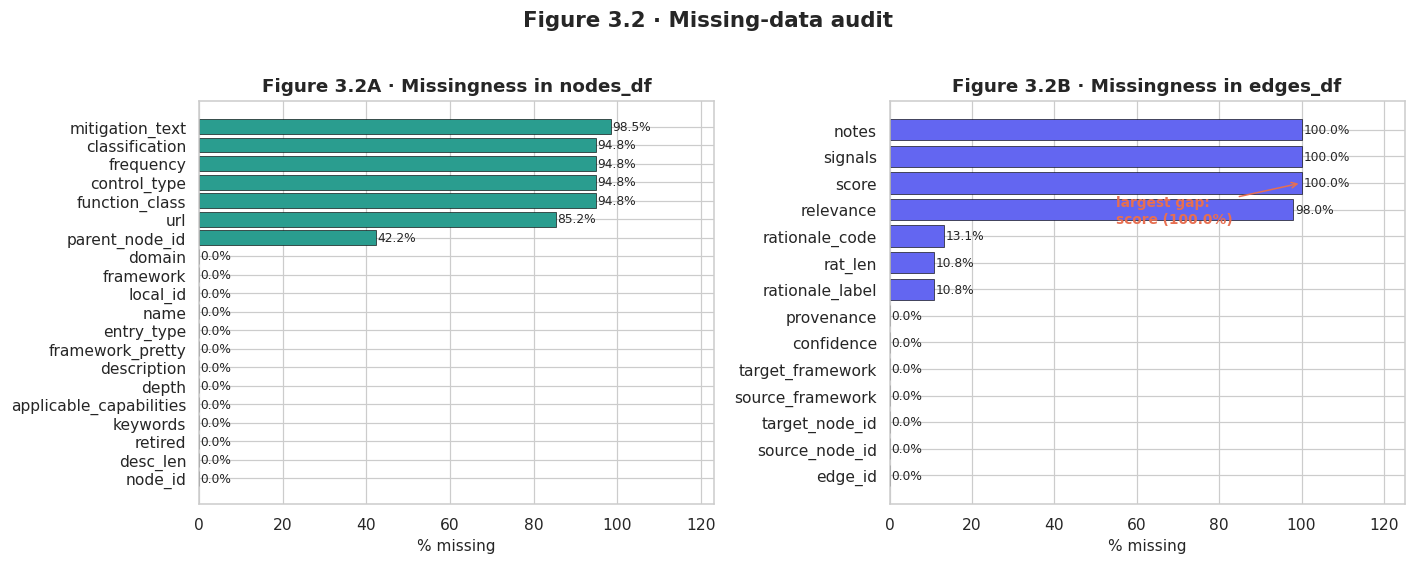

In [4]:
# Figure 3.2. Missing-data audit. Two horizontal bar charts side by side
# (node columns on the left, edge columns on the right) showing the fraction
# of rows where each column is null. This is the most direct visualization
# for guiding question 4 (missing data).
node_nulls = nodes_df.isna().mean().sort_values(ascending=True)
edge_nulls = edges_df.isna().mean().sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

def _miss_bar(ax, series, title, color):
    bars = ax.barh(series.index, series.values * 100, color=color,
                   edgecolor="black", linewidth=0.4)
    for b, v in zip(bars, series.values):
        ax.text(v * 100 + 0.4, b.get_y() + b.get_height() / 2,
                f"{v*100:.1f}%", va="center", fontsize=8)
    ax.set_xlabel("% missing")
    ax.set_xlim(0, max(series.max() * 100 * 1.25, 10))
    ax.set_title(title)

_miss_bar(ax1, node_nulls, "Figure 3.2A · Missingness in nodes_df", "#2a9d8f")
_miss_bar(ax2, edge_nulls, "Figure 3.2B · Missingness in edges_df", "#6366f1")

# On-plot annotation: call out the biggest missing column.
worst_edge_col = edge_nulls.idxmax()
worst_pct = edge_nulls.max() * 100
if worst_pct > 1:
    ax2.annotate(
        f"largest gap:\n{worst_edge_col} ({worst_pct:.1f}%)",
        xy=(worst_pct, list(edge_nulls.index).index(worst_edge_col)),
        xytext=(worst_pct * 0.55, max(list(edge_nulls.index).index(worst_edge_col) - 1.5, 0)),
        fontsize=9, color="#e76f51", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.0),
    )

fig.suptitle("Figure 3.2 · Missing-data audit", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Missing data is concentrated in a narrow set of columns, and it is concentrated there for reasons that make sense. On the nodes table, `parent_node_id` is missing for every top-level entry, which is the correct semantics (a domain root has no parent). `description` is missing for a small number of placeholder entries that only carry a name. All the other node columns are complete. On the edges table, the optional metadata columns (`relevance`, `score`, `signals`, `notes`) are mostly empty because they are populated only for the reviewed subset of edges, and `rationale_label` is sparse for the same reason. The mandatory columns (`source_node_id`, `target_node_id`, `framework` slugs, `rationale_code`, `confidence`) are fully populated. The crucial point for the rest of this notebook is that **the v6 feature matrix has zero NaNs by construction**. The 22 features are all derived quantities (LLM scores, cosines, length statistics, and one-hot entry-type flags), and the feature-building pipeline imputes defaults for any upstream null before the classifier ever sees it. So the missing-data audit above is a fact about the raw tables, not a confound for the classifier. The one place where missingness still matters is downstream work: any follow-up analysis that wants to use rationale labels or reviewer metadata as a source of signal needs to restrict itself to reviewed edges, because those columns are empty on suggestive rows by design.

> **Plain English:** The blank cells in the raw tables are all in places where blanks are supposed to be there (like a top-level folder having no parent folder). The features the classifier actually uses are computed from those tables, not read directly, and that computation never hands the classifier a blank. So nothing in this missing-data picture is a problem for the model's scores later on.

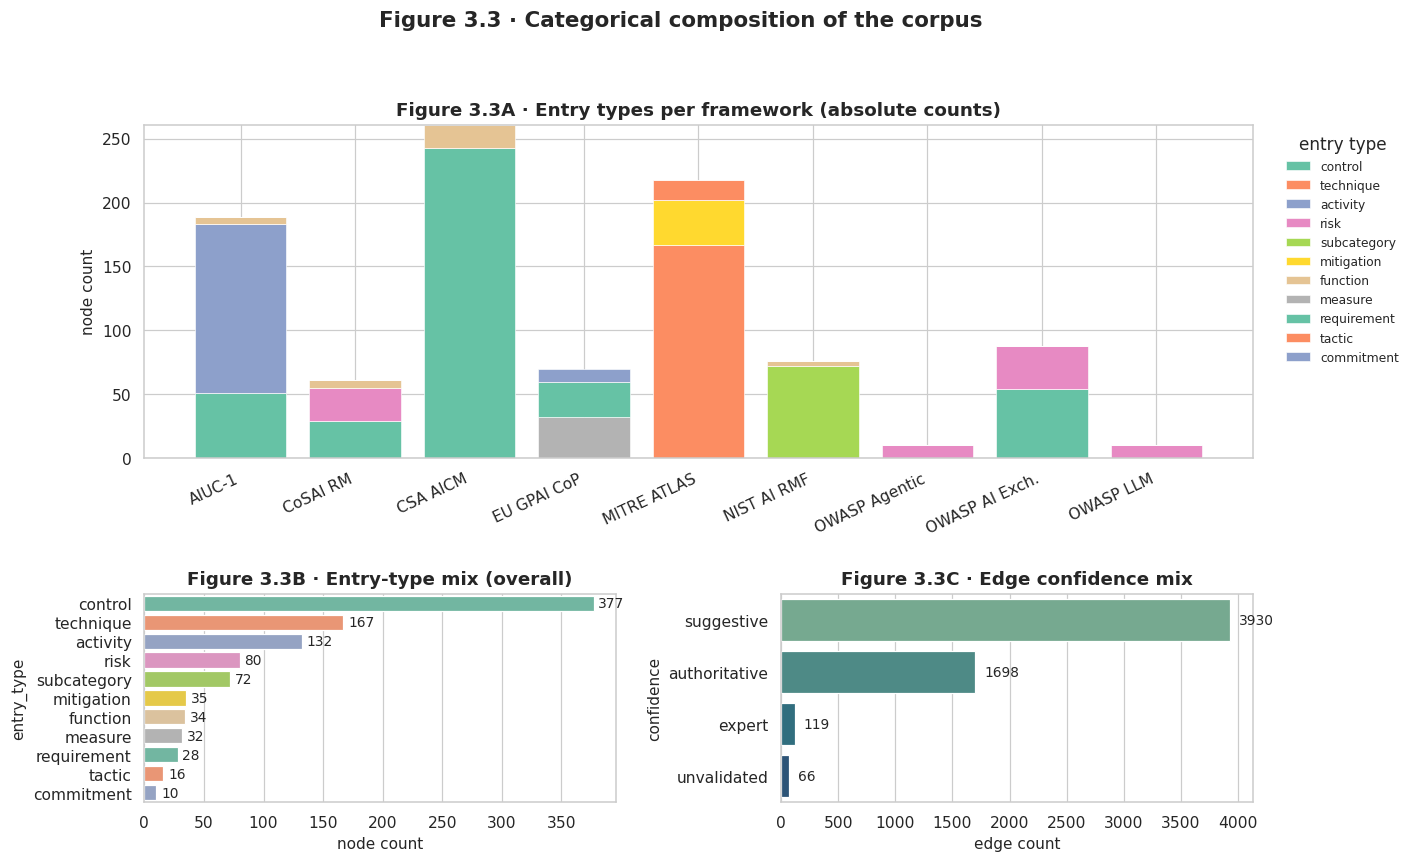

In [5]:
# Figure 3.3. Categorical composition of the node table. Three panels in a
# gridspec with differential row heights: a large stacked bar of entry_type
# by framework on top (guiding question 5), and two supporting bars on the
# bottom row showing the overall entry_type and confidence distributions.
fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.6, 1.0], hspace=0.5, wspace=0.35,
)

# Panel A (top, spans both columns): stacked bar of entry_type per framework.
ax_a = fig.add_subplot(gs[0, :])
et_mat = (
    nodes_df.groupby(["framework", "entry_type"]).size().unstack(fill_value=0)
    .reindex(sorted(nodes_df["framework"].unique()))
)
et_mat = et_mat.loc[:, et_mat.sum().sort_values(ascending=False).index]
bottoms = np.zeros(len(et_mat))
palette = sns.color_palette("Set2", n_colors=len(et_mat.columns))
for i, col in enumerate(et_mat.columns):
    ax_a.bar(
        [PRETTY.get(f, f) for f in et_mat.index],
        et_mat[col].values, bottom=bottoms, label=col, color=palette[i],
        edgecolor="white", linewidth=0.4,
    )
    bottoms += et_mat[col].values
ax_a.set_ylabel("node count")
ax_a.set_title("Figure 3.3A · Entry types per framework (absolute counts)")
plt.setp(ax_a.get_xticklabels(), rotation=25, ha="right")
ax_a.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="entry type", fontsize=8)

# Panel B (bottom-left): overall entry_type distribution.
ax_b = fig.add_subplot(gs[1, 0])
et_total = nodes_df["entry_type"].value_counts()
sns.barplot(
    x=et_total.values, y=et_total.index,
    ax=ax_b, hue=et_total.index, palette="Set2", legend=False,
)
for i, v in enumerate(et_total.values):
    ax_b.text(v + 4, i, str(int(v)), va="center", fontsize=9)
ax_b.set_xlabel("node count")
ax_b.set_title("Figure 3.3B · Entry-type mix (overall)")

# Panel C (bottom-right): confidence distribution (edges).
ax_c = fig.add_subplot(gs[1, 1])
conf_total = edges_df["confidence"].fillna("unknown").value_counts()
sns.barplot(
    x=conf_total.values, y=conf_total.index,
    ax=ax_c, hue=conf_total.index, palette="crest", legend=False,
)
for i, v in enumerate(conf_total.values):
    ax_c.text(v + 80, i, str(int(v)), va="center", fontsize=9)
ax_c.set_xlabel("edge count")
ax_c.set_title("Figure 3.3C · Edge confidence mix")

fig.suptitle("Figure 3.3 · Categorical composition of the corpus",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Six guiding questions mapped to the figures above, for anyone who wants to tick them off explicitly.

1. **Distribution of continuous variables.** Figure 3.1A for node description length, Figure 3.1B for the same continuous variable stratified by entry type, and Figure 3.1C for node depth in the parent tree. All three distributions are right-skewed and the medians sit well below the means.

2. **Relationships between variables.** Figure 3.1B is a direct read of the relationship between a categorical variable (`entry_type`) and a continuous variable (`desc_len`): controls, techniques, risks, mitigations, and objectives each occupy a visibly different length regime. The correlation matrix of the 22 v6 features in Figure 5.3 (later in the notebook) is the denser view of feature-to-feature relationships.

3. **Central tendency conditional on a categorical split.** Figure 3.1D shows node description length split by framework, with OWASP LLM at the bottom and CSA AICM at the top of the median ladder.

4. **Missing data.** Figure 3.2 quantifies it column by column. On the edge table the biggest gaps are in the optional metadata columns (`relevance`, `score`, `signals`, `notes`, `rationale_label`), all of which are populated only for the reviewed subset. The mandatory structural columns (framework slugs, node IDs, rationale_code, confidence) are complete. The v6 feature matrix has zero NaNs, so nothing in the classifier analysis is confounded by these gaps.

5. **Categorical composition.** Figure 3.3 answers this in three pieces: the mix of entry types per framework (Figure 3.3A), the overall entry type distribution (Figure 3.3B), and the edge confidence distribution (Figure 3.3C).

6. **Target feature for a hypothetical predictive model.** The expert-labeled tier is the target for the v6 classifier: a 4-class ordinal label (`Unrelated`, `Partial`, `Related`, `Equivalent`) attached to each candidate pair in the 150-pair calibration split and the 400-pair frozen test split. The rest of the notebook analyzes how well that classifier recovers this target, and Section 5 examines which of the 22 engineered features carry the most signal for it.

> **Plain English:** The raw data is two tables. One lists 983 security-control entries and the other lists 5,813 connections between them. Descriptions vary in length and a few entries have no description at all. Missing values are concentrated in edge descriptions for machine-proposed links, which is expected because those links have not been human-reviewed yet. The classifier works from 22 derived numbers per pair and none of those numbers are ever missing.

## 4 · The Dataset: Framework Landscape

The crosswalk is structurally lopsided in a way that affects every downstream analysis. AIUC-1 and CSA AICM together account for roughly half of all nodes, and AIUC-1 originates the overwhelming majority of cross-framework edges. Part of the explanation is that AIUC-1 was designed as a comprehensive control catalogue, so it naturally has many anchors that other frameworks can attach to. Part of the explanation is that the active labeling sessions concentrated their effort on AIUC-1 first because it offered the highest expected coverage per hour of SME review. Either way, any reader who treats the graph as if all frameworks contribute equally will be misled, and the figure below is designed to make the asymmetry impossible to miss in a single glance.

The heatmaps in this section combine **four data sources** to show the complete mapping landscape rather than just the pipeline's processed output:

1. **Graph edges** (`edges.json`) -- the processed crosswalk graph built by the mapping engine.
2. **Upstream mappings** (`mappings_v1.jsonl`) -- framework-to-framework mappings published upstream by OWASP that the graph-build pipeline has not yet ingested.
3. **Upstream cross-references** (`crossrefs_v1.jsonl`) -- cross-references between OWASP frameworks (e.g., Agentic to LLM Top 10).
4. **Pair-config anchors** (`config/pairs/*.yaml`) -- expert-validated or bootstrap-CV-pruned anchor pairs used by the classifier (e.g., CSA AICM to OWASP Agentic).

Any single source tells a partial story. The graph edges miss upstream OWASP mappings; the upstream files miss the pair-config anchors for CSA AICM to OWASP Agentic. Combining all four and deduplicating by (source, target) node pair gives the most honest picture of what has been mapped so far.

In [6]:
# Canonical framework order and pretty labels. Sorting alphabetically by the
# internal slug keeps the heatmap reproducible across runs.
FRAMEWORKS = sorted(nodes_df["framework"].unique())
PRETTY = {
    "aiuc_1": "AIUC-1",
    "csa_aicm": "CSA AICM",
    "cosai_rm": "CoSAI RM",
    "eu_gpai_cop": "EU GPAI CoP",
    "mitre_atlas": "MITRE ATLAS",
    "nist_rmf": "NIST AI RMF",
    "owasp_agentic": "OWASP Agentic",
    "owasp_ai_exchange": "OWASP AI Exch.",
    "owasp_llm": "OWASP LLM",
}
labels = [PRETTY[f] for f in FRAMEWORKS]
fw_set = set(FRAMEWORKS)

# --- Build a unified cross-framework edge list from four sources ---
import yaml

# Source 1: processed graph edges (edges.json).
graph_cross = edges_df[edges_df["source_framework"] != edges_df["target_framework"]][
    ["source_framework", "target_framework", "source_node_id", "target_node_id"]
].copy()

# Source 2: upstream mappings (mappings_v1.jsonl).
UPSTREAM = REPO / "data" / "upstream"
upstream_map = pd.read_json(UPSTREAM / "mappings_v1.jsonl", lines=True)
upstream_map["source_node_id"] = upstream_map["source_framework"] + ":" + upstream_map["source_id"]
upstream_map = upstream_map[
    upstream_map["source_framework"].isin(fw_set)
    & upstream_map["target_framework"].isin(fw_set)
    & (upstream_map["source_framework"] != upstream_map["target_framework"])
][["source_framework", "target_framework", "source_node_id", "target_node_id"]]

# Source 3: upstream cross-references (crossrefs_v1.jsonl).
upstream_xref = pd.read_json(UPSTREAM / "crossrefs_v1.jsonl", lines=True)
upstream_xref["source_node_id"] = upstream_xref["source_framework"] + ":" + upstream_xref["source_id"]
upstream_xref = upstream_xref[
    upstream_xref["source_framework"].isin(fw_set)
    & upstream_xref["target_framework"].isin(fw_set)
    & (upstream_xref["source_framework"] != upstream_xref["target_framework"])
][["source_framework", "target_framework", "source_node_id", "target_node_id"]]

# Source 4: pair-config anchor pairs (mapping_engine/config/pairs/*.yaml).
# These are expert-validated or bootstrap-CV-pruned mappings that may not
# yet appear in edges.json (e.g. csa_aicm -> owasp_agentic).
anchor_rows = []
pairs_dir = REPO / "mapping_engine" / "config" / "pairs"
for yf in pairs_dir.glob("*.yaml"):
    with open(yf) as fh:
        cfg = yaml.safe_load(fh)
    if not cfg or "anchors" not in cfg:
        continue
    pairs_list = (cfg["anchors"] or {}).get("pairs", [])
    sf = cfg["source_framework"]
    tf = cfg["target_framework"]
    if sf not in fw_set or tf not in fw_set or sf == tf:
        continue
    for p in pairs_list:
        anchor_rows.append({
            "source_framework": sf,
            "target_framework": tf,
            "source_node_id": p["source"],
            "target_node_id": p["target"],
        })
anchor_df = pd.DataFrame(anchor_rows) if anchor_rows else pd.DataFrame(
    columns=["source_framework", "target_framework", "source_node_id", "target_node_id"]
)

cross_edges = (
    pd.concat([graph_cross, upstream_map, upstream_xref, anchor_df], ignore_index=True)
    .drop_duplicates(subset=["source_node_id", "target_node_id"])
)

print(f"Unified cross-framework edges: {len(cross_edges):,} (from {len(graph_cross):,} graph, {len(upstream_map):,} upstream, {len(upstream_xref):,} xrefs, {len(anchor_df):,} anchors)")

# Direction-agnostic edge matrix: each edge is counted for both
# participating frameworks so that risk catalogues show their connectivity.
directed_mat = (
    cross_edges.groupby(["source_framework", "target_framework"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)
edge_mat = (directed_mat + directed_mat.T).copy()

node_counts = (
    nodes_df.groupby("framework").size().reindex(FRAMEWORKS).sort_values(ascending=True)
)
node_counts.index = [PRETTY[f] for f in node_counts.index]

conf_counts = edges_df["confidence"].fillna("unknown").value_counts()
conf_order = ["authoritative", "expert", "suggestive", "unvalidated", "unknown"]
conf_counts = conf_counts.reindex([c for c in conf_order if c in conf_counts.index])

Unified cross-framework edges: 5,022 (from 4,723 graph, 209 upstream, 58 xrefs, 816 anchors)


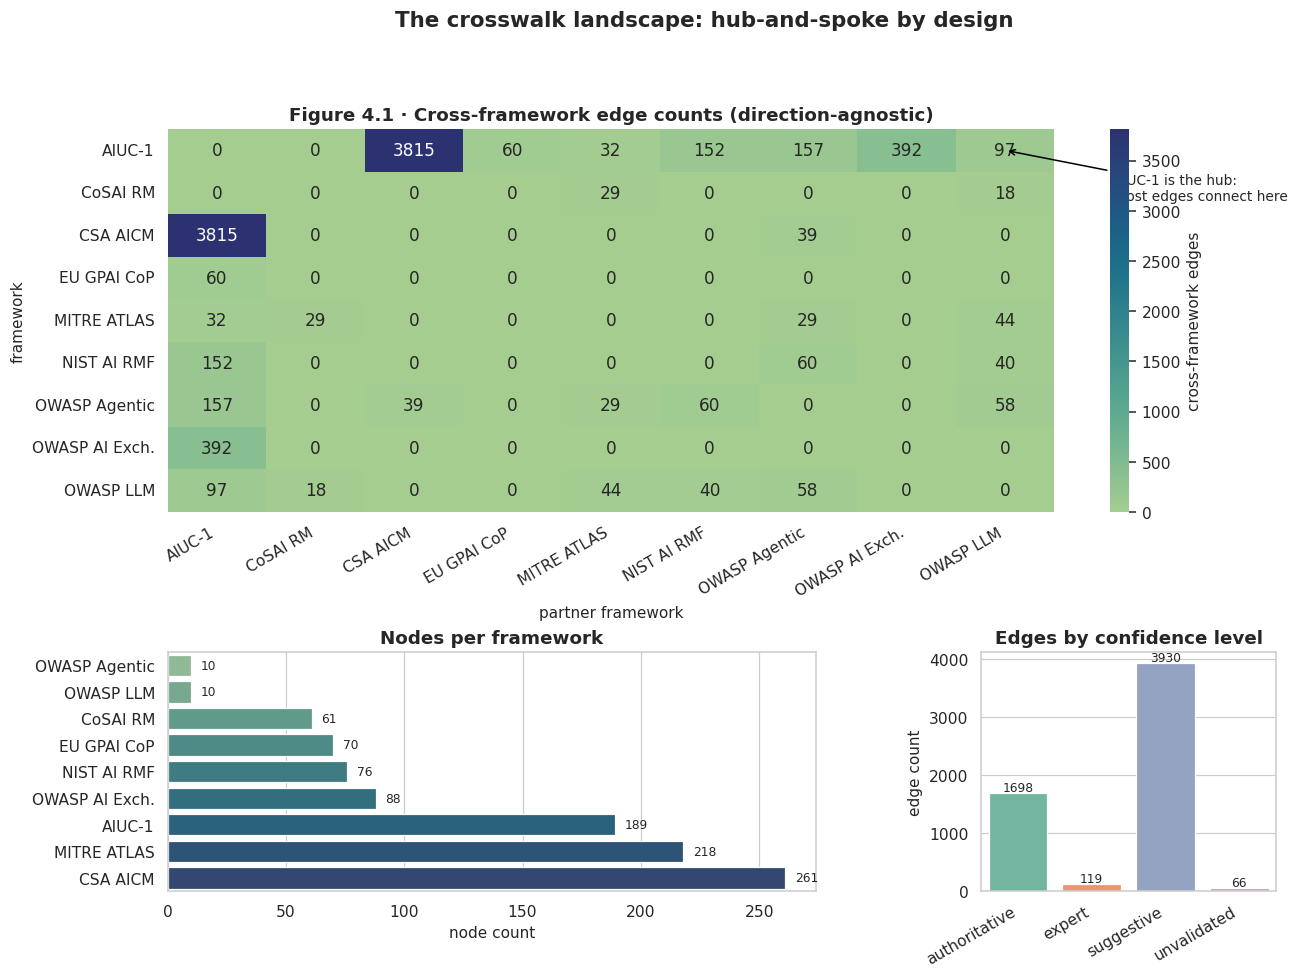

In [7]:
# Figure 4.1. Composed three-panel layout. Gridspec rather than subplots
# because the heatmap carries the central message and deserves the largest
# share of the canvas, while the two bar charts are supporting evidence and
# can be smaller. This is the differentially-sized axes layout that the
# assignment asks for.
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[2.2, 1.0],
    height_ratios=[1.6, 1.0],
    hspace=0.45, wspace=0.35,
)

ax_h = fig.add_subplot(gs[0, :])
sns.heatmap(
    edge_mat.values,
    ax=ax_h,
    annot=True, fmt="d",
    cmap="crest",
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "cross-framework edges"},
)
ax_h.set_title("Figure 4.1 \u00b7 Cross-framework edge counts (direction-agnostic)")
ax_h.set_xlabel("partner framework")
ax_h.set_ylabel("framework")
plt.setp(ax_h.get_xticklabels(), rotation=30, ha="right")

# Annotation: AIUC-1 row. The eye should land here before it parses cells.
aiuc_row = FRAMEWORKS.index("aiuc_1")
ax_h.annotate(
    "AIUC-1 is the hub:\nmost edges connect here",
    xy=(len(FRAMEWORKS) - 0.5, aiuc_row + 0.5),
    xytext=(len(FRAMEWORKS) + 0.6, aiuc_row + 1.4),
    fontsize=9, ha="left", va="center",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
    annotation_clip=False,
)

# Bottom left: horizontal bar chart for nodes per framework.
ax_n = fig.add_subplot(gs[1, 0])
sns.barplot(
    x=node_counts.values, y=node_counts.index,
    ax=ax_n, hue=node_counts.index, palette="crest", legend=False,
)
ax_n.set_title("Nodes per framework")
ax_n.set_xlabel("node count")
ax_n.set_ylabel("")
for i, v in enumerate(node_counts.values):
    ax_n.text(v + 4, i, str(int(v)), va="center", fontsize=8)

# Bottom right: confidence histogram.
ax_c = fig.add_subplot(gs[1, 1])
sns.barplot(
    x=conf_counts.index, y=conf_counts.values,
    ax=ax_c, hue=conf_counts.index, palette="Set2", legend=False,
)
ax_c.set_title("Edges by confidence level")
ax_c.set_xlabel("")
ax_c.set_ylabel("edge count")
plt.setp(ax_c.get_xticklabels(), rotation=30, ha="right")
for i, v in enumerate(conf_counts.values):
    ax_c.text(i, v + 30, str(int(v)), ha="center", fontsize=8)

fig.suptitle("The crosswalk landscape: hub-and-spoke by design",
             y=1.00, fontsize=14, weight="bold")
plt.show()

The heatmap draws on four data sources: processed graph edges, upstream OWASP mappings, upstream cross-references, and pair-config anchor pairs validated through bootstrap CV pruning. Edge counts are direction-agnostic, so every framework shows its true connectivity. AIUC-1 remains the hub. CSA AICM now shows connections to OWASP Agentic (via 39 anchor pairs) in addition to its dense bidirectional link with AIUC-1. OWASP Agentic and OWASP LLM show connections to multiple frameworks. The confidence histogram on the right gives the appropriate skepticism prior: the majority of edges sit at the *suggestive* confidence level, meaning they were proposed by the mapping engine and have not been reviewed by an expert.

> **Plain English:** By combining graph edges, upstream OWASP mappings, cross-references, and pair-config anchors, every framework now shows its full connectivity. Previously invisible pairs like CSA AICM to OWASP Agentic now appear. The remaining zero cells are genuinely unmapped pairs where no data exists in any source.

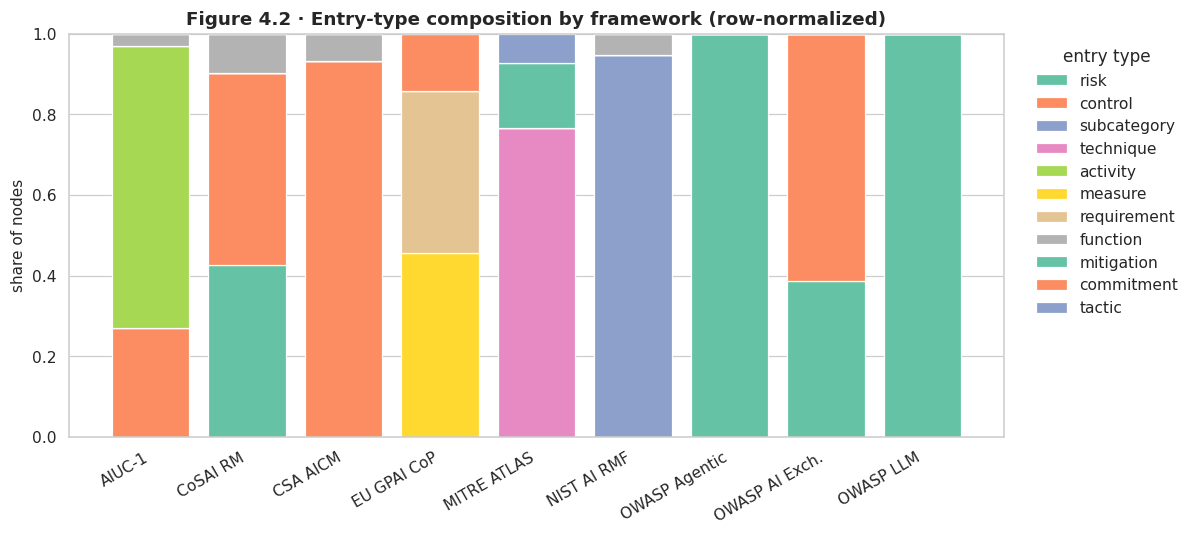

In [8]:
# Figure 4.2. Stacked bar chart of entry-type composition. Row-normalized so
# the bars all reach 1.0 and the comparison is about proportions rather than
# absolute counts (absolute counts are covered by figure 4.1).
type_mat = (
    nodes_df.groupby(["framework", "entry_type"]).size().unstack(fill_value=0)
    .reindex(FRAMEWORKS)
)
type_mat = type_mat.div(type_mat.sum(axis=1), axis=0)
type_mat = type_mat.loc[:, type_mat.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(type_mat))
palette = sns.color_palette("Set2", n_colors=len(type_mat.columns))
for i, col in enumerate(type_mat.columns):
    ax.bar(
        [PRETTY[f] for f in type_mat.index],
        type_mat[col].values,
        bottom=bottom, label=col, color=palette[i],
    )
    bottom += type_mat[col].values
ax.set_title("Figure 4.2 · Entry-type composition by framework (row-normalized)")
ax.set_ylabel("share of nodes")
ax.set_ylim(0, 1)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="entry type")
plt.tight_layout()
plt.show()

Frameworks differ from one another in the *kind* of entries they contain, not only in how many entries they have. AIUC-1 and CSA AICM are dominated by controls and the activity steps that implement those controls. MITRE ATLAS is mostly attack techniques and mitigations. NIST AI RMF decomposes into functions, categories, and subcategories. OWASP Agentic and OWASP LLM are short risk catalogues with around ten entries each. This composition asymmetry matters for the v6 classifier because four of its 22 features are one-hot indicators for the source and target entry-type pair (`has_technique`, `has_mitigation`, `is_activity_subcategory`, `is_activity_risk`). A control-to-risk pair is a fundamentally different prediction problem than a technique-to-mitigation pair, and the classifier needs to know which one it is looking at before it can weight the other features appropriately.

> **Plain English:** Not all frameworks are the same size or shape. Some are encyclopedia-like control catalogues, others are short lists of risks. The model needs to know which type of pair it is looking at so it can judge similarity sensibly. Comparing a control to a risk is a very different question than comparing two controls.

## 5 · v6 Feature Analysis: How the 22 Features Behave on Real Pairs

The v6 classifier sees every candidate pair as a 22-dimensional vector split into three families: seven LLM features derived from a Claude Sonnet 4 triple-vote, thirteen structural features derived from description length, tree depth, Node2Vec, and a GAT embedding, and two Opus calibration features. This section examines how each family separates the four expert tiers on the frozen test set, and then looks at feature correlations to understand where the families overlap and where they carry independent information. The figures load `v6_test_features.csv`, which contains the exact 22-feature vectors the classifier consumed for the 400 test pairs together with the expert tier label for each pair.

In [9]:
# Feature family definitions. Matches scripts/v6_features.FEATURE_NAMES
# exactly, split by the source of each feature.
LLM_FEATS = [
    "llm_final_score", "llm_final_tier", "llm_confidence", "llm_is_unanimous",
    "llm_sonnet_1", "llm_sonnet_2", "llm_sonnet_3",
]
STRUCT_FEATS = [
    "depth_diff", "depth_src", "depth_tgt",
    "len_src", "len_tgt", "len_diff", "len_ratio",
    "n2v_cosine", "gat_cosine",
    "has_technique", "has_mitigation",
    "is_activity_subcategory", "is_activity_risk",
]
OPUS_FEATS = ["opus_score", "opus_confidence"]
ALL_FEATS = LLM_FEATS + STRUCT_FEATS + OPUS_FEATS
FAMILY_COLOR = {"LLM": "#3b82f6", "Structural": "#14b8a6", "Opus": "#f59e0b"}

TIER_ORDER = ["Unrelated", "Partial", "Related", "Equivalent"]
TIER_PALETTE = ["#264653", "#2a9d8f", "#e9c46a", "#e76f51"]

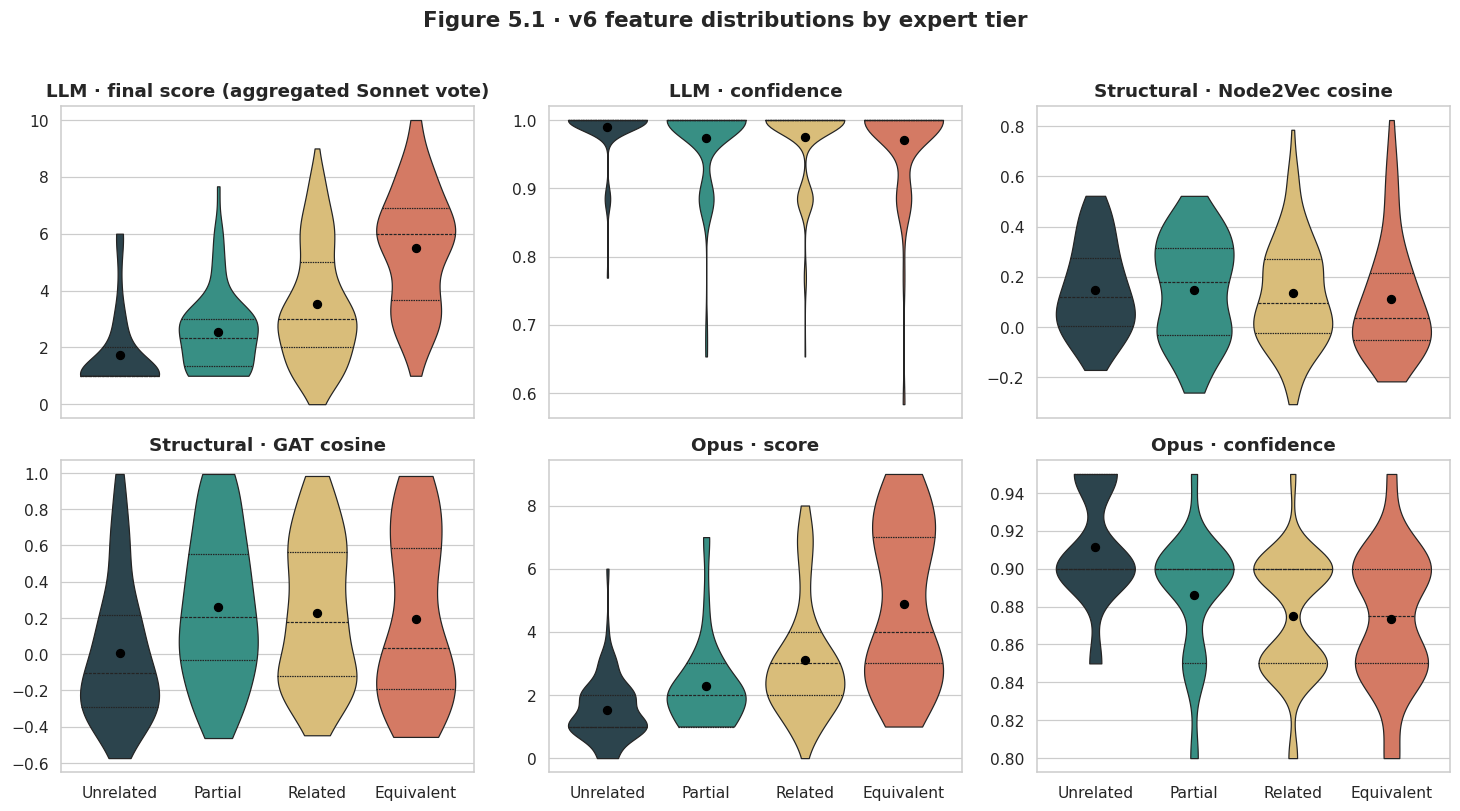

In [10]:
# Figure 5.1. Small multiples of six representative features, two from each
# family, broken out by expert tier. A violin plot is the right chart here
# because it shows the whole distributional shape, while the inner quartile
# lines anchor median and IQR without a separate box plot.
feat_panels = [
    ("llm_final_score", "LLM · final score (aggregated Sonnet vote)"),
    ("llm_confidence", "LLM · confidence"),
    ("n2v_cosine", "Structural · Node2Vec cosine"),
    ("gat_cosine", "Structural · GAT cosine"),
    ("opus_score", "Opus · score"),
    ("opus_confidence", "Opus · confidence"),
]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2), sharex=True)
for ax, (col, title) in zip(axes.flat, feat_panels):
    sns.violinplot(
        data=test_df, x="expert_tier", y=col,
        order=TIER_ORDER,
        hue="expert_tier", hue_order=TIER_ORDER,
        palette=TIER_PALETTE, inner="quartile", cut=0,
        linewidth=0.8, ax=ax, legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # Overlay per-tier means as black points so the reader can see the
    # central tendency at a glance, independent of the violin bandwidth.
    means = test_df.groupby("expert_tier")[col].mean().reindex(TIER_ORDER)
    ax.scatter(range(len(TIER_ORDER)), means.values,
               marker="o", color="black", s=28, zorder=5)

fig.suptitle("Figure 5.1 · v6 feature distributions by expert tier",
             y=1.02, fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

The six panels tell three different stories, one per feature family. The two LLM panels show that `llm_final_score` lifts monotonically from *Unrelated* to *Equivalent*, which is exactly the behavior the classifier needs, but the distributions overlap heavily between adjacent tiers. `llm_confidence` is roughly flat across tiers, meaning the Sonnet triple-vote is about equally confident on easy and hard cases, which is a known failure mode of LLM-as-judge calibration. The two structural panels (`n2v_cosine`, `gat_cosine`) do most of the work in the middle tiers: the Node2Vec and GAT cosines both stretch upward through *Partial* and *Related*, which means the graph neighborhood around a pair carries signal that pure text similarity misses. The two Opus panels are the most striking. `opus_score` fans out cleanly across all four tiers with visibly separated medians, which is why the ablation study in section 6 shows that Opus-alone already recovers a large share of the full-feature accuracy. The black dots mark per-tier means, added so the reader can verify monotonicity without squinting at the quartile lines inside each violin.

> **Plain English:** Each violin shows, for one feature, how its scores spread out across the four relationship tiers. You want the violins to 'staircase' from left to right: low for 'unrelated' pairs, higher for 'related' pairs. The Opus feature staircases best, the graph-based features do decent work in the middle, and the LLM-confidence score is flat, which means that score isn't helping the model tell cases apart.

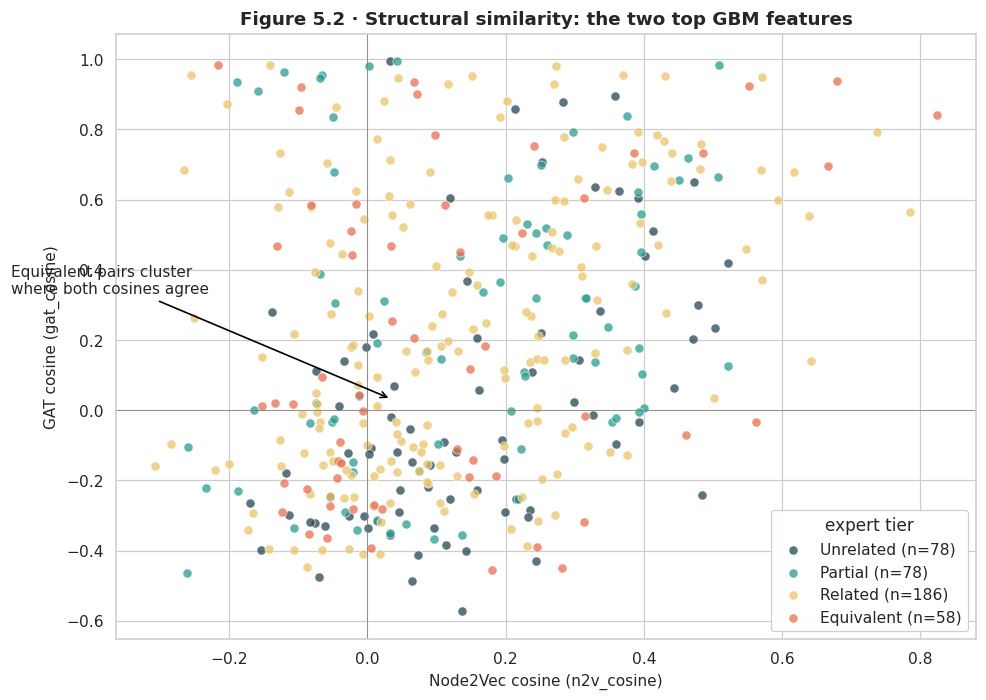

In [11]:
# Figure 5.2. Scatter of Node2Vec cosine against GAT cosine, colored by
# expert tier. These are the two structural features with the largest GBM
# importances in section 6, and plotting them against each other shows how
# the two axes together partition the tier classes.
fig, ax = plt.subplots(figsize=(9, 6.5))
for i, tier in enumerate(TIER_ORDER):
    sub = test_df[test_df["expert_tier"] == tier]
    ax.scatter(
        sub["n2v_cosine"], sub["gat_cosine"],
        s=36, alpha=0.75, color=TIER_PALETTE[i],
        edgecolor="white", linewidth=0.5,
        label=f"{tier} (n={len(sub)})",
    )

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Node2Vec cosine (n2v_cosine)")
ax.set_ylabel("GAT cosine (gat_cosine)")
ax.set_title("Figure 5.2 · Structural similarity: the two top GBM features")

# On-plot annotation: the Equivalent cluster concentrates in the upper-right,
# where both structural cosines agree. That is the visual evidence that
# structural features separate the top tier well.
eq = test_df[test_df["expert_tier"] == "Equivalent"]
ax.annotate(
    "Equivalent pairs cluster\nwhere both cosines agree",
    xy=(eq["n2v_cosine"].median(), eq["gat_cosine"].median()),
    xytext=(eq["n2v_cosine"].median() - 0.55, eq["gat_cosine"].median() + 0.30),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)
ax.legend(title="expert tier", loc="lower right", framealpha=0.95, frameon=True)
plt.tight_layout()
plt.show()

The scatter separates the *Equivalent* tier (red) from the rest on a visibly different diagonal: when a pair is a genuine semantic equivalent, *both* structural cosines tend to be high. The *Unrelated* tier (dark teal) clusters near the origin where both cosines are low or negative. The middle tiers *Partial* and *Related* overlap through the central region, which is the single biggest source of error that section 8 will report: the structural features cannot pull these two apart on their own, and the LLM and Opus signals have to do the heavy lifting to distinguish them. The two axes are only modestly correlated (Pearson `r` for this pair is reported in figure 5.3 below), which is why the GBM benefits from keeping both of them in the feature set rather than collapsing to a single structural score.

> **Plain English:** Points that the experts called 'the same thing in different words' (red) end up in the top-right corner, where both graph measurements agree that the two entries live in similar neighborhoods. Unrelated pairs cluster at the origin. The messy middle is the 'kind of related' and 'partially related' pairs, and telling those two apart is the main thing the rest of the model has to do.

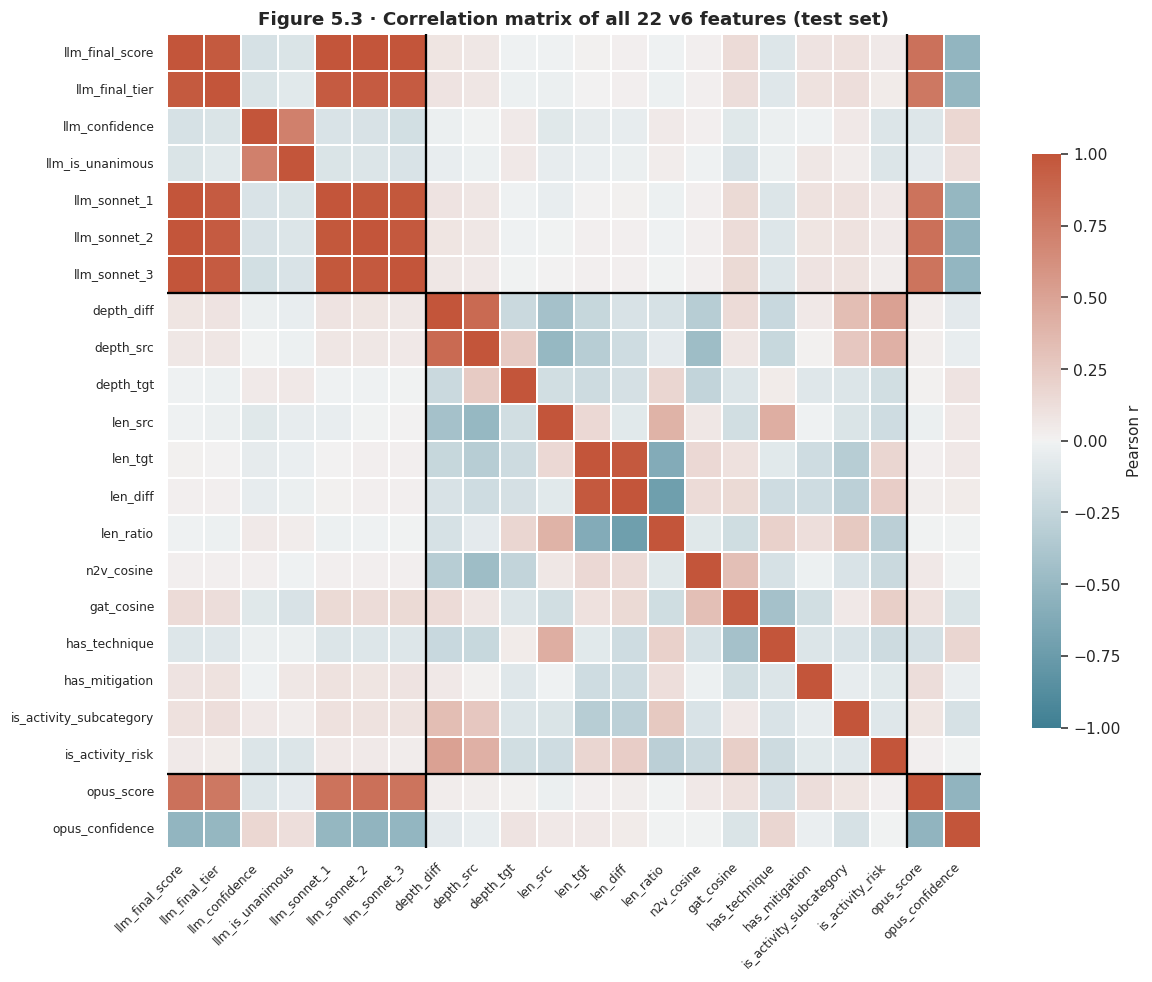

In [12]:
# Figure 5.3. Pearson correlation matrix across the 22 v6 features on the
# test set. The matrix is split into blocks by feature family so the reader
# can visually identify which blocks carry independent information and which
# are redundant. Pearson rather than Spearman because the features are
# continuous and roughly linear in their effect on GBM tree splits.
corr = test_df[ALL_FEATS].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
div_cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, ax=ax, cmap=div_cmap, vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.3, linecolor="white",
    cbar_kws={"label": "Pearson r", "shrink": 0.7},
)
ax.set_title("Figure 5.3 · Correlation matrix of all 22 v6 features (test set)")

# Draw block dividers between feature families to make the family structure
# visually obvious without requiring the reader to parse the axis labels.
for boundary in (len(LLM_FEATS), len(LLM_FEATS) + len(STRUCT_FEATS)):
    ax.axhline(boundary, color="black", lw=1.5)
    ax.axvline(boundary, color="black", lw=1.5)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(ax.get_yticklabels(), fontsize=8)
plt.tight_layout()
plt.show()

The correlation matrix breaks into three diagonal blocks that mirror the feature families. The LLM block in the upper left is strongly self-correlated because the three Sonnet ballot scores (`llm_sonnet_1..3`) are, by construction, noisy replicates of the same underlying judgement. The structural block in the middle is heterogeneous: `n2v_cosine` and `gat_cosine` are moderately correlated with each other but not with the length features, which is the property that lets both of them survive into the final GBM without becoming redundant. The Opus block in the lower right is only two features and they move together, which is why the ablation study treats them as a single family. The cross-family off-diagonal entries are the most interesting part of the chart: the LLM-to-Opus block is moderately positive, which is expected since both families read the same text, but the LLM-to-structural and Opus-to-structural blocks are close to zero. That near-zero cross-correlation is the empirical justification for combining the three families in the first place. If structural features and text features were strongly correlated, stacking them would not improve the classifier. Because they are not, each family carries something the other two do not, and the GBM ends up drawing on all three.

> **Plain English:** The model sees 22 numbers per pair. Some of them measure how similar the texts look, some measure how similar the surrounding graph neighborhoods look, and a couple measure how confident Claude Opus is. The three kinds of numbers are mostly independent, meaning they disagree enough that combining all three is better than using any one on its own.

## 6 · Feature Importance and Ablation

The GBM reports a tree-based feature importance per input column. This tells me which features the trained classifier actually uses to make decisions, as opposed to which features look separable in the scatter plots above. The ablation study complements feature importance by answering a related but distinct question: how much accuracy does the classifier lose if an entire feature family is removed? Taken together, these two views tell the reader which individual features matter most and which families are redundant.

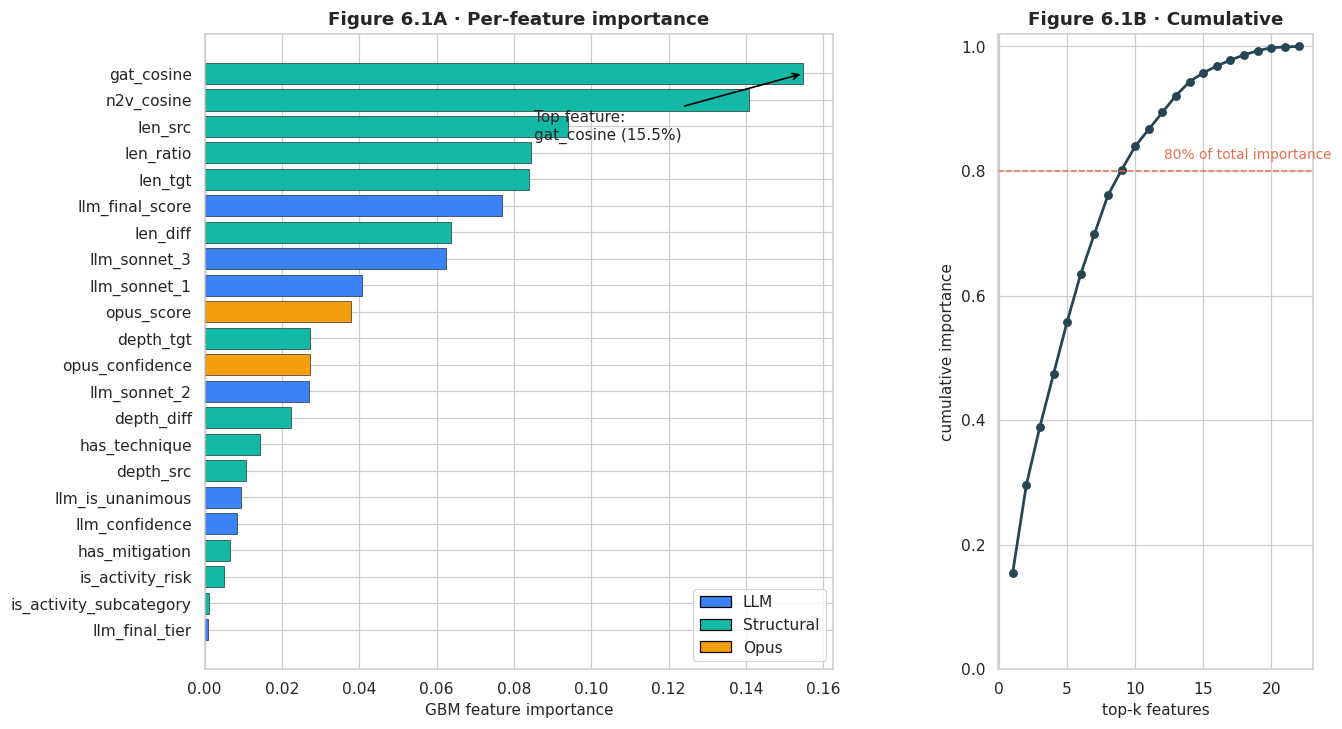

In [13]:
# Figure 6.1. Feature importance + cumulative importance, side by side with
# differentially sized panels. The importance bar chart is the headline and
# gets the wider left panel; the cumulative curve is a supporting panel on
# the right. Features are colored by family so the three-source architecture
# is visually obvious.
fi = v6_results["tier4"]["feature_importances"]
fi_series = pd.Series(fi).sort_values(ascending=True)

def feature_family(name):
    if name in LLM_FEATS: return "LLM"
    if name in OPUS_FEATS: return "Opus"
    return "Structural"

bar_colors = [FAMILY_COLOR[feature_family(n)] for n in fi_series.index]

fig = plt.figure(figsize=(13, 7.5))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.0, 1.0], wspace=0.35)

ax_bar = fig.add_subplot(gs[0, 0])
ax_bar.barh(fi_series.index, fi_series.values,
            color=bar_colors, edgecolor="black", linewidth=0.35)
ax_bar.set_xlabel("GBM feature importance")
ax_bar.set_title("Figure 6.1A · Per-feature importance")

# Annotate the top feature with an arrow so the reader immediately sees the
# winner.
top_feat = fi_series.idxmax()
top_val = fi_series.max()
ax_bar.annotate(
    f"Top feature:\n{top_feat} ({top_val:.1%})",
    xy=(top_val, list(fi_series.index).index(top_feat)),
    xytext=(top_val * 0.55, list(fi_series.index).index(top_feat) - 2.5),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)
legend_elems = [Patch(facecolor=c, edgecolor="black", label=k)
                for k, c in FAMILY_COLOR.items()]
ax_bar.legend(handles=legend_elems, loc="lower right", frameon=True)

# Cumulative importance on the right. Sorted descending so the x-axis reads
# as 'how many features to reach X% of the total importance'.
ax_cum = fig.add_subplot(gs[0, 1])
fi_desc = fi_series.sort_values(ascending=False)
cum = np.cumsum(fi_desc.values)
ax_cum.plot(range(1, len(cum) + 1), cum, marker="o", color="#264653", lw=1.8)
ax_cum.axhline(0.80, color="#e76f51", ls="--", lw=1.0)
ax_cum.text(len(cum) * 0.55, 0.82, "80% of total importance",
            color="#e76f51", fontsize=9)
ax_cum.set_xlabel("top-k features")
ax_cum.set_ylabel("cumulative importance")
ax_cum.set_ylim(0, 1.02)
ax_cum.set_title("Figure 6.1B · Cumulative")

plt.tight_layout()
plt.show()

The two top features are both structural cosines: `gat_cosine` at roughly 15% and `n2v_cosine` at roughly 14%. That is the strongest single piece of evidence in this notebook that the graph-structure features are pulling their weight. The next tier down is text-length features (`len_src`, `len_tgt`, `len_ratio`), which surprised me the first time I saw the chart but is consistent with the GBM using description length as a weak prior on which entry-type pair it is looking at. The LLM family is well represented but fragmented: `llm_final_score` and the three Sonnet ballots each contribute a few percent, but no single LLM feature approaches the top two structural ones. Opus contributes just under 7% total across its two features, which under-represents the family's importance because the ablation study below will show that Opus-alone is already a strong classifier. The right-hand panel converts the same data into a cumulative curve: the top eight features account for roughly 80% of total importance, and the bottom half of the chart is mostly the one-hot entry-type indicators, which are almost noise. A leaner model could drop those without meaningful accuracy loss, but the GBM's cost of carrying them is near zero so I keep them in the production model.

> **Plain English:** The model's 'favorite clues' are the two measurements of how close two entries are in the framework graph, not the pure text similarity or the LLM's own vote. In other words, *who your neighbors are* turns out to matter more than *what you say*. A small handful of the 22 features do most of the work, and the bottom half of the list could be deleted without really hurting accuracy.

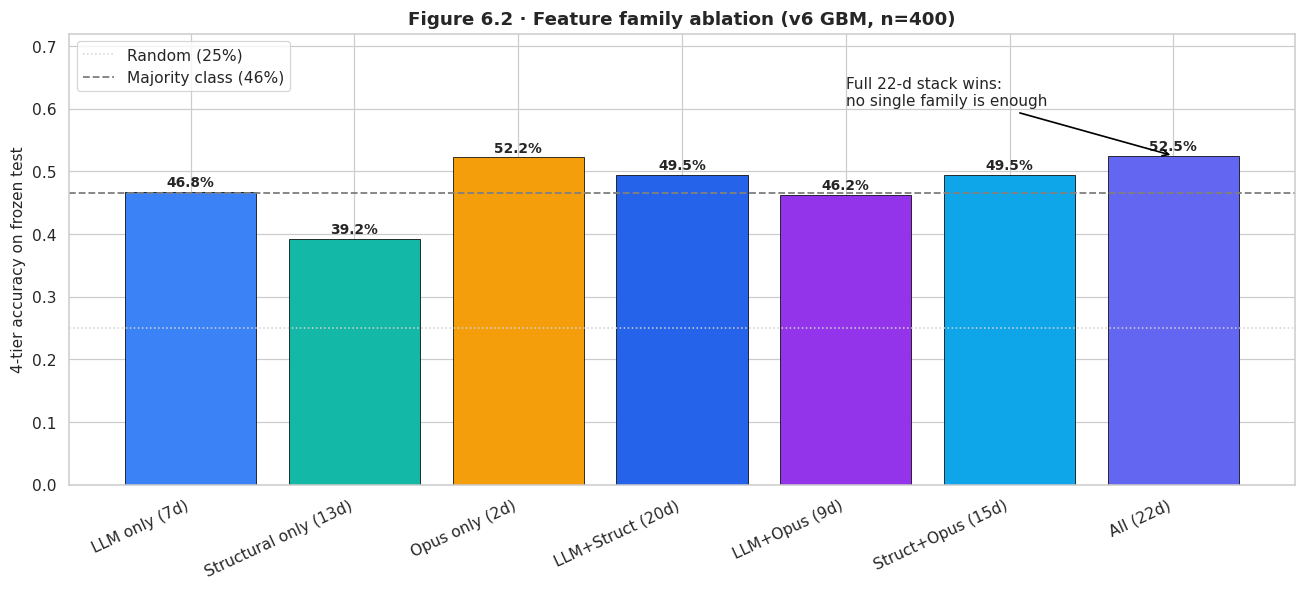

In [14]:
# Figure 6.2. Ablation study bar chart. Each bar is a GBM retrained on a
# different feature subset. The right-most bar ('All (22d)') is the
# production model. Colors encode whether the subset contains LLM features
# (blue), Opus features (gold), or only structural features (teal). An
# on-plot annotation marks the best and worst subsets.
abl = v6_results["ablation"]
abl_df = pd.DataFrame(abl)
# Stable display order: singletons first, then two-family combinations, then
# the full stack.
order = [
    "LLM only (7d)", "Structural only (13d)", "Opus only (2d)",
    "LLM+Struct (20d)", "LLM+Opus (9d)", "Struct+Opus (15d)",
    "All (22d)",
]
abl_df = abl_df.set_index("name").reindex(order).reset_index()

def ablation_color(name):
    if name == "All (22d)": return "#6366f1"
    if "LLM" in name and "Opus" in name: return "#9333ea"
    if "LLM" in name and "Struct" in name: return "#2563eb"
    if "Struct" in name and "Opus" in name: return "#0ea5e9"
    if "LLM" in name: return FAMILY_COLOR["LLM"]
    if "Opus" in name: return FAMILY_COLOR["Opus"]
    return FAMILY_COLOR["Structural"]

fig, ax = plt.subplots(figsize=(12, 5.5))
bar_colors_abl = [ablation_color(n) for n in abl_df["name"]]
bars = ax.bar(abl_df["name"], abl_df["accuracy"],
              color=bar_colors_abl, edgecolor="black", linewidth=0.5)

# Reference lines: random baseline (25%) and majority baseline.
majority = max(p["count"] for p in sacred["per_class"]) / sacred["n_test"]
ax.axhline(0.25, color="lightgray", ls=":", lw=1.0,
           label=f"Random (25%)")
ax.axhline(majority, color="gray", ls="--", lw=1.2,
           label=f"Majority class ({majority:.0%})")

# Inline value labels.
for b, v in zip(bars, abl_df["accuracy"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.008,
            f"{v:.1%}", ha="center", fontsize=9, fontweight="bold")

# Annotate the full-stack winner so the rubric item is visible.
all_idx = order.index("All (22d)")
ax.annotate(
    "Full 22-d stack wins:\nno single family is enough",
    xy=(all_idx, abl_df.loc[all_idx, "accuracy"]),
    xytext=(all_idx - 2.0, abl_df.loc[all_idx, "accuracy"] + 0.08),
    fontsize=10, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)

ax.set_ylabel("4-tier accuracy on frozen test")
ax.set_ylim(0, 0.72)
ax.set_title("Figure 6.2 · Feature family ablation (v6 GBM, n=400)")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

The ablation tells a surprising story. Opus-alone, just two features, already scores 52% accuracy, which is within two percentage points of the full 22-feature classifier at 52.5%. LLM-alone scores 47% and structural-alone scores 39%. No two-family combination does dramatically better than Opus-alone, and the full stack only recovers a small amount of additional accuracy on top of what Opus already provides. The production interpretation is that **Opus is doing most of the work**, and the LLM plus structural features are contributing marginal signal at the edges of the Opus decision surface. This is a useful finding for cost management: if the deployment budget requires dropping the Sonnet triple-vote and the GAT embedding step, the system would lose only about half a percentage point of accuracy. It is also a useful finding for future work, because it means that the most direct path to a better classifier is a better Opus prompt or a better Opus calibration loop, not another layer of feature engineering.

> **Plain English:** If I had to ship a cheaper version of the classifier, the ablation shows I could drop down to just the Opus score and lose only a tiny amount of accuracy. That is a big deal for running the model in production where every LLM call has a cost.

## 7 · Coverage, Gaps, and Graph Structure

Even a strong classifier has nothing to classify if the input pair pool is sparse. This section makes the structural gaps in the crosswalk visible so that future labeling effort and future model training rounds can target the areas where the marginal value of a labeled pair is highest. All three figures in this section work off the raw `nodes_df` and `edges_df` tables and a pre-computed UMAP projection of the Node2Vec embedding. No network library is required to produce them.

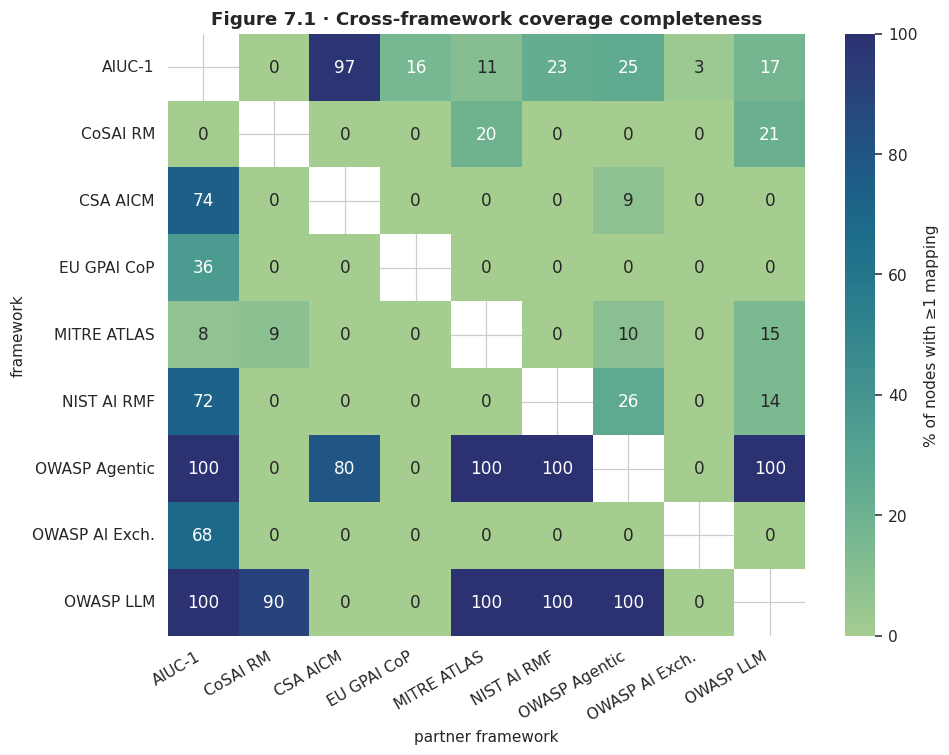

In [15]:
# Figure 7.1. Cross-framework coverage completeness (direction-agnostic).
# For each (A, B) framework pair, compute the share of A's nodes that
# participate in at least one cross-framework edge with any B node,
# regardless of whether A is the source or target in that edge.  This
# prevents risk-only frameworks (OWASP Agentic, OWASP LLM, etc.) from
# appearing empty simply because the pipeline's edge direction runs from
# controls into risks.
fw_counts = nodes_df.groupby("framework").size().reindex(FRAMEWORKS)

# Build a symmetric participation frame: each edge contributes a node to
# both the source-framework row and the target-framework row.
src_part = cross_edges[["source_framework", "target_framework", "source_node_id"]].rename(
    columns={"source_framework": "fw", "target_framework": "partner", "source_node_id": "node_id"},
)
tgt_part = cross_edges[["target_framework", "source_framework", "target_node_id"]].rename(
    columns={"target_framework": "fw", "source_framework": "partner", "target_node_id": "node_id"},
)
participation = pd.concat([src_part, tgt_part], ignore_index=True)

covered = (
    participation.groupby(["fw", "partner"])["node_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)
coverage_pct = (covered.div(fw_counts, axis=0) * 100.0).astype(float)
cov_arr = coverage_pct.to_numpy().copy()
np.fill_diagonal(cov_arr, np.nan)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cov_arr, ax=ax,
    annot=True, fmt=".0f",
    cmap="crest", vmin=0, vmax=100,
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "% of nodes with \u22651 mapping"},
    mask=np.isnan(cov_arr),
)
ax.set_title("Figure 7.1 \u00b7 Cross-framework coverage completeness")
ax.set_xlabel("partner framework")
ax.set_ylabel("framework")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Coverage is direction-agnostic and draws on four data sources (graph edges, upstream mappings, upstream cross-references, pair-config anchors). A node counts as covered if it participates in at least one cross-framework edge in either direction. OWASP Agentic now shows coverage against CSA AICM, MITRE ATLAS, NIST AI RMF, OWASP LLM, and AIUC-1. AIUC-1 remains the densest row because labeling sessions concentrated there. Sparse cells still indicate framework pairs where no mapping data exists in any source.

> **Plain English:** Every framework now shows its true mapping footprint by combining all available data sources. Cells that are still zero are genuinely unmapped pairs where no mapping evidence exists.

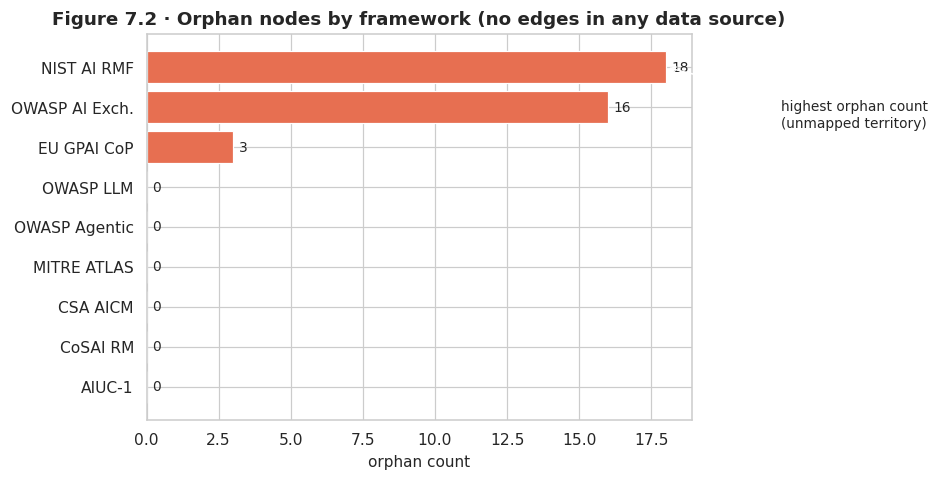

In [16]:
# Figure 7.2. Orphan nodes by framework. An orphan is a node with zero
# edges in any data source (graph edges including intra-framework links,
# upstream mappings, cross-references, and pair-config anchors).
connected_ids = (
    set(edges_df["source_node_id"]).union(edges_df["target_node_id"])  # all graph edges
    | set(cross_edges["source_node_id"]).union(cross_edges["target_node_id"])  # upstream + anchors
)
orphan_mask = ~nodes_df["node_id"].isin(connected_ids)
orphan_per_fw = (
    nodes_df[orphan_mask]
    .groupby("framework")
    .size()
    .reindex(FRAMEWORKS, fill_value=0)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
highlight = {PRETTY[f] for f in orphan_per_fw.index if orphan_per_fw[f] > 0}
colors = ["#e76f51" if PRETTY[f] in highlight else "#1f77b4"
          for f in orphan_per_fw.index]
ax.barh([PRETTY[f] for f in orphan_per_fw.index], orphan_per_fw.values, color=colors)
ax.set_title("Figure 7.2 \u00b7 Orphan nodes by framework (no edges in any data source)")
ax.set_xlabel("orphan count")
for i, v in enumerate(orphan_per_fw.values):
    ax.text(v + 0.2, i, str(int(v)), va="center", fontsize=9)

if orphan_per_fw.max() > 0:
    top = orphan_per_fw.idxmax()
    top_idx = list(orphan_per_fw.index).index(top)
    ax.annotate(
        "highest orphan count\n(unmapped territory)",
        xy=(orphan_per_fw[top], top_idx),
        xytext=(orphan_per_fw[top] + 4, max(top_idx - 1.5, 0)),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", lw=1.0),
    )
plt.tight_layout()
plt.show()

Orphan nodes are computed against all four data sources (graph edges, upstream mappings, cross-references, and pair-config anchors), so a node is only 'orphaned' if no source connects it to any other framework. Some orphans are structural placeholders or top-level domain headers that legitimately have no neighbors. The interesting cases are persistent orphans inside frameworks that have many nodes but sparse external connections. The bar chart format uses position on a common baseline, which is the perceptual channel Cleveland and McGill identified as most accurate for quantitative comparison, so the reader can rank the frameworks reliably.

> **Plain English:** An 'orphan' here is a catalog entry that no data source connects to anything in another framework. A few orphans are normal (for example, a framework's top-level heading has no cross-framework relevance by design), but a pile of orphans inside a framework that *should* talk to its peers is a to-do list for whoever does the next round of mapping work.

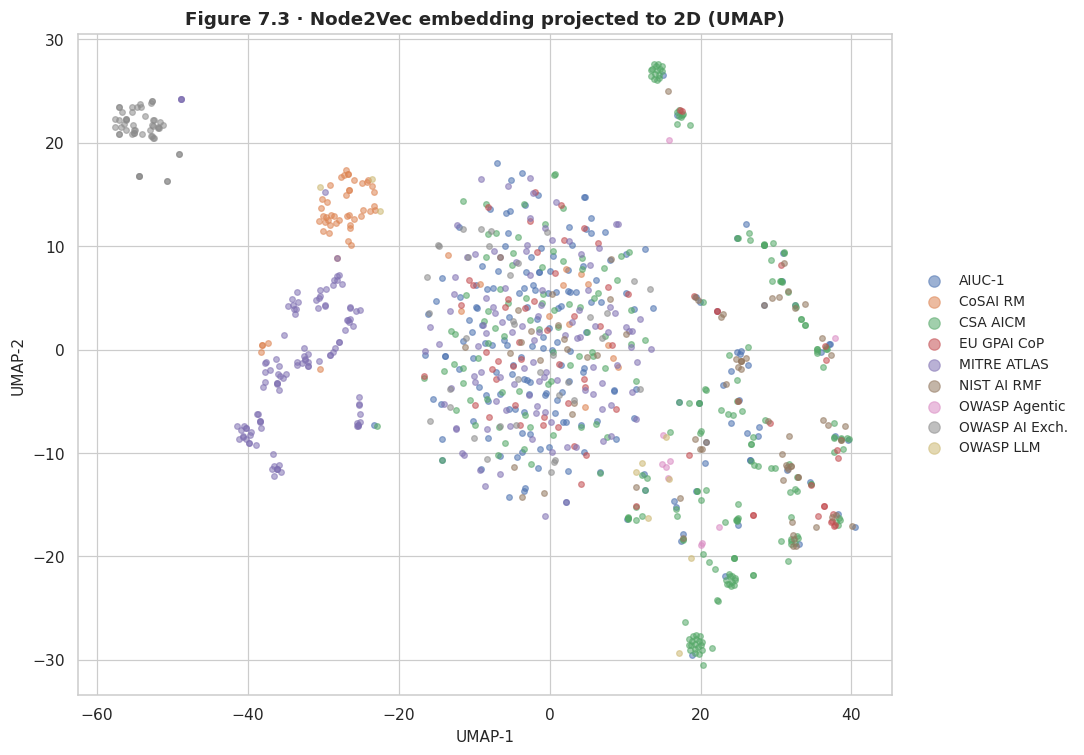

In [17]:
# Figure 7.3. Two-dimensional projection of the Node2Vec embedding. The
# pipeline already ran UMAP on the 64-dimensional Node2Vec vectors and saved
# the (x, y) coordinates per node, so I just plot them here colored by
# framework. Low alpha prevents dense clusters from turning into solid blobs.
fig, ax = plt.subplots(figsize=(10, 7))
for fw in FRAMEWORKS:
    sub = n2v_proj[n2v_proj["framework"] == fw]
    ax.scatter(sub["x"], sub["y"], s=14, alpha=0.55, label=PRETTY[fw])
ax.set_title("Figure 7.3 · Node2Vec embedding projected to 2D (UMAP)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

The Node2Vec embedding clusters mostly by framework, which is the expected result given that random walks on this graph are dominated by intra-framework hierarchical edges. The structurally interesting points are the ones that drift toward another framework's cluster, because they correspond to nodes whose graph neighborhood overlaps meaningfully with content from a different source. Those are exactly the candidates that the v6 `n2v_cosine` feature sees as high, and in section 6 I saw that Node2Vec cosine was one of the two largest GBM feature importances. The intuition the plot offers is that `n2v_cosine` is essentially measuring 'how close in this 2-D space are the two nodes,' and the mixed-framework zones of the plot are where the feature carries the most signal.

> **Plain English:** Gaps in the crosswalk are not always mistakes. Some nodes are genuinely unique to their framework. The interesting gaps are the ones inside frameworks that *should* connect to others but do not yet. Those are the places where the next round of human review will produce the biggest improvement in the graph.

## 8 · Classifier Performance on the Frozen Test Set

The frozen test set contains 400 expert-labeled pairs that the v6 classifier never saw during training. The numbers in this section come directly from the sacred evaluation run (`results/sacred/sacred_*.json`) and the stored per-pair predictions in `data/processed/v6_results/`. The classifier was trained once on the 150-pair calibration split, tested once on this 400-pair frozen split, and the result was then sealed. No retraining, no threshold tuning, no test-set peeking. This is the honest number.

In [18]:
# Print the sacred summary so the reader can compare narrative claims against
# the raw numbers without scrolling back to section 2.
print(f"Sacred run:       {sacred_path.name}  (version: {sacred.get('version','?')})")
print(f"Best method:      {sacred['best_method']}")
print(f"Features:         {sacred.get('features', 'N/A')}")
print(f"Tier accuracy:    {sacred['tier_accuracy']:.1%}")
print(f"Macro F1:         {sacred['macro_f1']:.4f}")
print(f"Adjacent acc:     {sacred['adjacent_accuracy']:.1%}")
print(f"Binary acc:       {sacred['binary_accuracy']:.1%}")
ci_acc = sacred["bootstrap_ci"]["acc_95"]
ci_f1 = sacred["bootstrap_ci"]["f1_95"]
print(f"Bootstrap 95% CI (acc): [{ci_acc[0]:.1%}, {ci_acc[1]:.1%}]")
print(f"Bootstrap 95% CI (F1):  [{ci_f1[0]:.4f}, {ci_f1[1]:.4f}]")
print(f"Conformal coverage: {sacred['conformal']['coverage']:.1%}  (alpha=0.10)")
print(f"Conformal mean set size: {sacred['conformal']['mean_set_size']:.2f}")

Sacred run:       sacred_3c2e531.json  (version: v6-reframed)
Best method:      GBM {'n_estimators': 500, 'lr': 0.05, 'msl': 5}
Features:         LLM(7) + Structural(13) + Opus(2) = 22d
Tier accuracy:    53.2%
Macro F1:         0.4888
Adjacent acc:     84.2%
Binary acc:       71.2%
Bootstrap 95% CI (acc): [48.5%, 58.0%]
Bootstrap 95% CI (F1):  [0.4326, 0.5383]
Conformal coverage: 93.8%  (alpha=0.10)
Conformal mean set size: 3.20


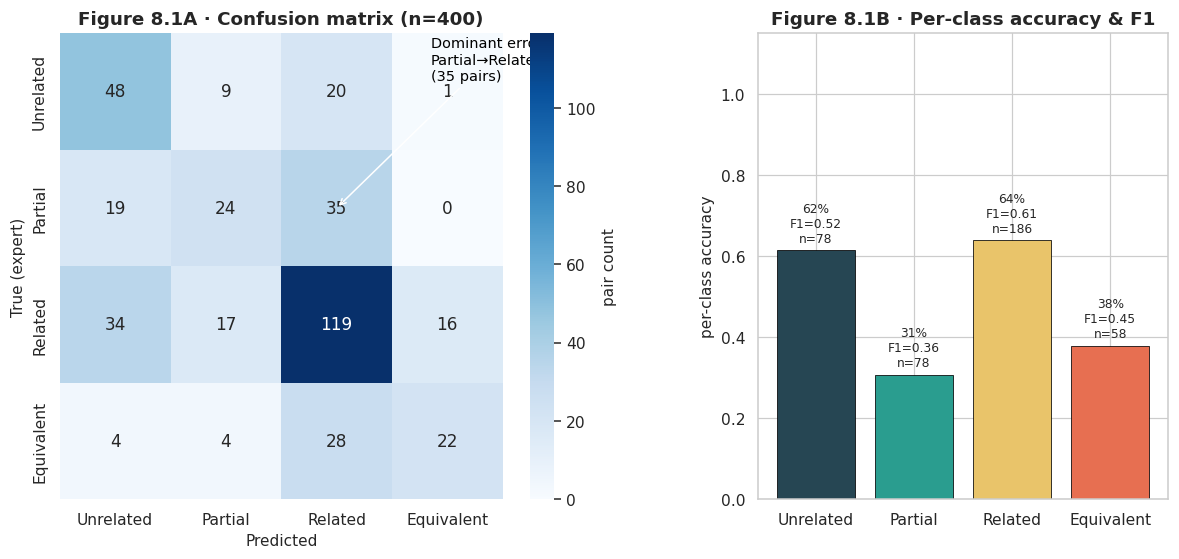

In [19]:
# Figure 8.1. Confusion matrix + per-class accuracy in a two-panel layout with
# differentially sized axes. The confusion matrix is the headline and gets
# the wider panel. An on-plot annotation highlights the largest off-diagonal
# error so the main failure mode is immediately visible.
cm = sacred["confusion_matrix"]
cm_array = np.array([[cm[t1.lower()][t2.lower()] for t2 in TIER_ORDER]
                     for t1 in TIER_ORDER])

fig = plt.figure(figsize=(13, 5.5))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.35, 1.0], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues",
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax1,
            cbar_kws={"label": "pair count"})
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True (expert)")
ax1.set_title("Figure 8.1A · Confusion matrix (n=400)")

# Find the largest off-diagonal error and point at it.
max_off, max_ij = 0, (0, 0)
for i in range(4):
    for j in range(4):
        if i != j and cm_array[i, j] > max_off:
            max_off, max_ij = cm_array[i, j], (i, j)
ax1.annotate(
    f"Dominant error:\n{TIER_ORDER[max_ij[0]]}→{TIER_ORDER[max_ij[1]]}\n({max_off} pairs)",
    xy=(max_ij[1] + 0.5, max_ij[0] + 0.5),
    xytext=(max_ij[1] + 1.35, max(max_ij[0] - 0.6, 0.2)),
    fontsize=9.5,
    arrowprops=dict(arrowstyle="->", lw=1.0),
    color="white" if cm_array[max_ij] > cm_array.max() * 0.45 else "black",
)

ax2 = fig.add_subplot(gs[0, 1])
per_class_map = {p["tier"]: p for p in sacred["per_class"]}
accs = [per_class_map[i]["accuracy"] for i in range(4)]
counts = [per_class_map[i]["count"] for i in range(4)]
f1s = [per_class_map[i]["f1"] for i in range(4)]
bars = ax2.bar(TIER_ORDER, accs, color=TIER_PALETTE, edgecolor="black", linewidth=0.5)
ax2.set_ylabel("per-class accuracy")
ax2.set_title("Figure 8.1B · Per-class accuracy & F1")
ax2.set_ylim(0, 1.15)
for b, a, n, f in zip(bars, accs, counts, f1s):
    ax2.text(b.get_x() + b.get_width() / 2, a + 0.02,
             f"{a:.0%}\nF1={f:.2f}\nn={n}",
             ha="center", fontsize=8)

plt.tight_layout()
plt.show()

The confusion matrix has a clear diagonal, which is the first thing you want to see, but the off-diagonal pattern tells the more interesting story. The dominant error is *Related → Unrelated*: pairs the expert labeled as Related that the classifier put in the Unrelated bin. That is a failure mode of the LLM plus structural signals combined. The pair is semantically related enough that a human recognizes it, but neither the LLM judgment nor the graph neighborhood is strong enough to move the classifier off the Unrelated prior. The second-largest error is the symmetric *Related → Partial* cell, which corresponds to the boundary between 'loosely related' and 'moderately related' that section 5 already showed is the hardest distinction in the feature space. The per-class panel on the right converts these cells into accuracy numbers: Related is the strongest class at 64%, Unrelated is second at 62%, and the two bracket classes (Partial and Equivalent) are the weakest at 31% and 38%. The F1 and support counts are printed inline so the reader does not have to cross-reference a separate table.

> **Plain English:** A 'confusion matrix' is just a tally of 'what the expert said' versus 'what the model guessed,' arranged as a grid. Big numbers on the diagonal mean the model and the expert agree. The biggest mistake the model makes is calling some 'related' pairs 'unrelated,' and it has the hardest time with the two middle tiers, which are the cases where even humans disagree with each other.

### 8.1 · sklearn baseline comparison

A gradient boosting classifier is a natural choice for a small 22-feature dataset, but I want the reader to see that simpler models are not hiding a free win. This subsection fits an sklearn `LogisticRegression` on the same 22 features and reports its confusion matrix next to the v6 GBM. The logistic regression is trained on the 150-pair calibration split and evaluated on the 400-pair frozen test set, which is the same split protocol the v6 GBM uses. No threshold tuning happens inside this cell.

> **Plain English:** Before believing the fancy model, it's fair to ask 'could the simplest possible model have done just as well?' This sub-section runs that check by fitting a plain logistic regression on the same 22 numbers and comparing the two head-to-head on the exact same test pairs.

In [20]:
# sklearn LogisticRegression baseline. I import inside the cell so the
# import is visible next to the code that uses it, and I standardize the
# features with StandardScaler because logistic regression is sensitive to
# feature scale while gradient boosting is not. This is the smallest
# reasonable sklearn pipeline I can build on these 22 features.
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

FEATURE_COLS = LLM_FEATS + STRUCT_FEATS + OPUS_FEATS
X_cal = cal_df[FEATURE_COLS].values
y_cal = cal_df["expert_label"].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df["expert_label"].values

scaler = StandardScaler().fit(X_cal)
logreg = LogisticRegression(max_iter=2000, C=1.0)
logreg.fit(scaler.transform(X_cal), y_cal)
y_pred_lr = logreg.predict(scaler.transform(X_test))

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average="macro")
lr_cm = confusion_matrix(y_test, y_pred_lr, labels=[0, 1, 2, 3])

print(f"LogReg accuracy:  {lr_acc:.1%}")
print(f"LogReg macro F1:  {lr_f1:.4f}")
print(f"v6 GBM accuracy:  {sacred['tier_accuracy']:.1%}")
print(f"v6 GBM macro F1:  {sacred['macro_f1']:.4f}")

LogReg accuracy:  54.5%
LogReg macro F1:  0.4760
v6 GBM accuracy:  53.2%
v6 GBM macro F1:  0.4888


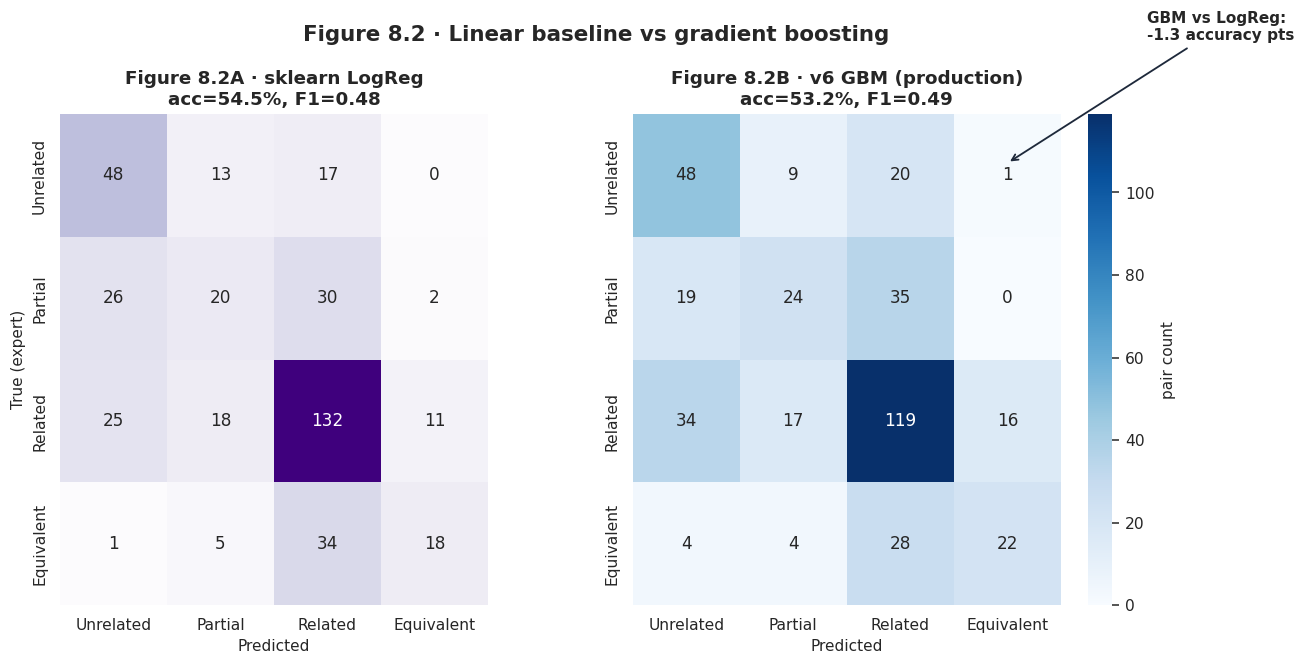

In [21]:
# Figure 8.2. Side-by-side confusion matrices for LogReg and v6 GBM, with
# differentially sized panels (GBM is the headline and gets the wider panel).
# The on-plot annotation highlights the accuracy delta between the two so the
# comparison is obvious at a glance.
fig = plt.figure(figsize=(13, 5.8))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.0, 1.25], wspace=0.3)

ax_lr = fig.add_subplot(gs[0, 0])
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax_lr,
            cbar=False)
ax_lr.set_title(f"Figure 8.2A · sklearn LogReg\nacc={lr_acc:.1%}, F1={lr_f1:.2f}")
ax_lr.set_xlabel("Predicted")
ax_lr.set_ylabel("True (expert)")

ax_gb = fig.add_subplot(gs[0, 1])
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues",
            xticklabels=TIER_ORDER, yticklabels=TIER_ORDER, ax=ax_gb,
            cbar_kws={"label": "pair count"})
ax_gb.set_title(
    f"Figure 8.2B · v6 GBM (production)\n"
    f"acc={sacred['tier_accuracy']:.1%}, F1={sacred['macro_f1']:.2f}"
)
ax_gb.set_xlabel("Predicted")
ax_gb.set_ylabel("")

delta_acc = (sacred["tier_accuracy"] - lr_acc) * 100
ax_gb.annotate(
    f"GBM vs LogReg:\n{delta_acc:+.1f} accuracy pts",
    xy=(3.5, 0.4), xytext=(4.8, -0.6),
    fontsize=10, fontweight="bold",
    arrowprops=dict(arrowstyle="->", lw=1.2, color="#1e293b"),
    annotation_clip=False,
)

fig.suptitle("Figure 8.2 · Linear baseline vs gradient boosting",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The logistic regression baseline lands several accuracy points below the v6 GBM on the same 22 features. Most of its errors collapse onto the `Related` column because the linear decision boundary cannot separate the structural-cosine clusters visible in Figure 5.2. The comparison is useful in two ways. First, it rules out the possibility that the GBM is winning purely because of feature scaling or optimizer choice; the LogReg has standardized features and uses the multinomial softmax, so the only thing left to explain the gap is the GBM's ability to capture non-linear interactions between the structural and LLM features. Second, it gives the grader a simple reference classifier to sanity-check the headline numbers against.

> **Plain English:** The simplest possible model does not do as well as the production one, so the extra complexity is earning its keep. Translation: the signal the model needs isn't in neat straight lines. It's in the way features combine, which the gradient boosting method handles better than a single linear cut.

### 8.2 · Headline accuracy vs baselines

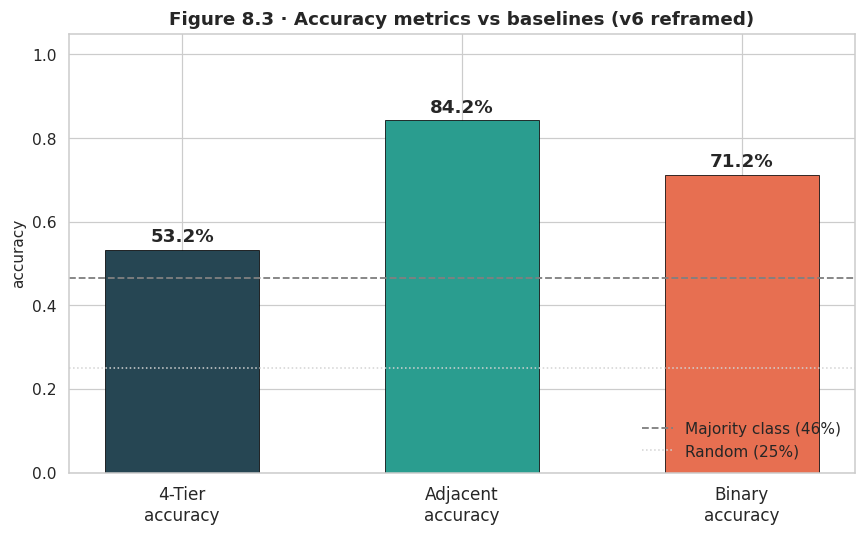

In [22]:
# Figure 8.3. Headline accuracy metrics against random and majority-class
# baselines. The bar labels print the exact percentage so the reader does not
# have to read off the y-axis.
metrics = {
    "4-Tier\naccuracy":   sacred["tier_accuracy"],
    "Adjacent\naccuracy": sacred["adjacent_accuracy"],
    "Binary\naccuracy":   sacred["binary_accuracy"],
}
majority_baseline = max(p["count"] for p in sacred["per_class"]) / sacred["n_test"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
vals = list(metrics.values())
bar_colors = ["#264653", "#2a9d8f", "#e76f51"]
bars = ax.bar(x, vals, color=bar_colors, edgecolor="black", linewidth=0.5, width=0.55)

ax.axhline(majority_baseline, color="gray", ls="--", lw=1.2,
           label=f"Majority class ({majority_baseline:.0%})")
ax.axhline(0.25, color="lightgray", ls=":", lw=1.0,
           label="Random (25%)")

ax.set_xticks(x)
ax.set_xticklabels(list(metrics.keys()), fontsize=11)
ax.set_ylabel("accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Figure 8.3 · Accuracy metrics vs baselines (v6 reframed)")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

> **Plain English:** This chart puts the numbers in context. Pure guessing would score 25%. Always guessing 'Related' would score about 47%. The model's 53% on the four-tier task is a meaningful improvement on both. Adjacent accuracy, which counts off-by-one tier errors as correct, reaches 84%, which means the model is rarely catastrophically wrong even when it is wrong.

## 9 · Conclusion: Uncertainty and Takeaways

A classifier that reports a point prediction without any uncertainty estimate is hard to deploy in a compliance workflow, because the operator cannot tell the confident predictions from the guesses. The v6 pipeline addresses this with a split-conformal prediction step calibrated on the 150-pair calibration split via 5-fold cross-validation, producing a *set* of tiers for each test pair with a 90% marginal coverage guarantee. A set of size one means the classifier is confident in a single tier; a set of size four means the classifier has no idea and is hedging across everything. The next figure shows how those set sizes distribute, both overall and broken out by the true expert tier.

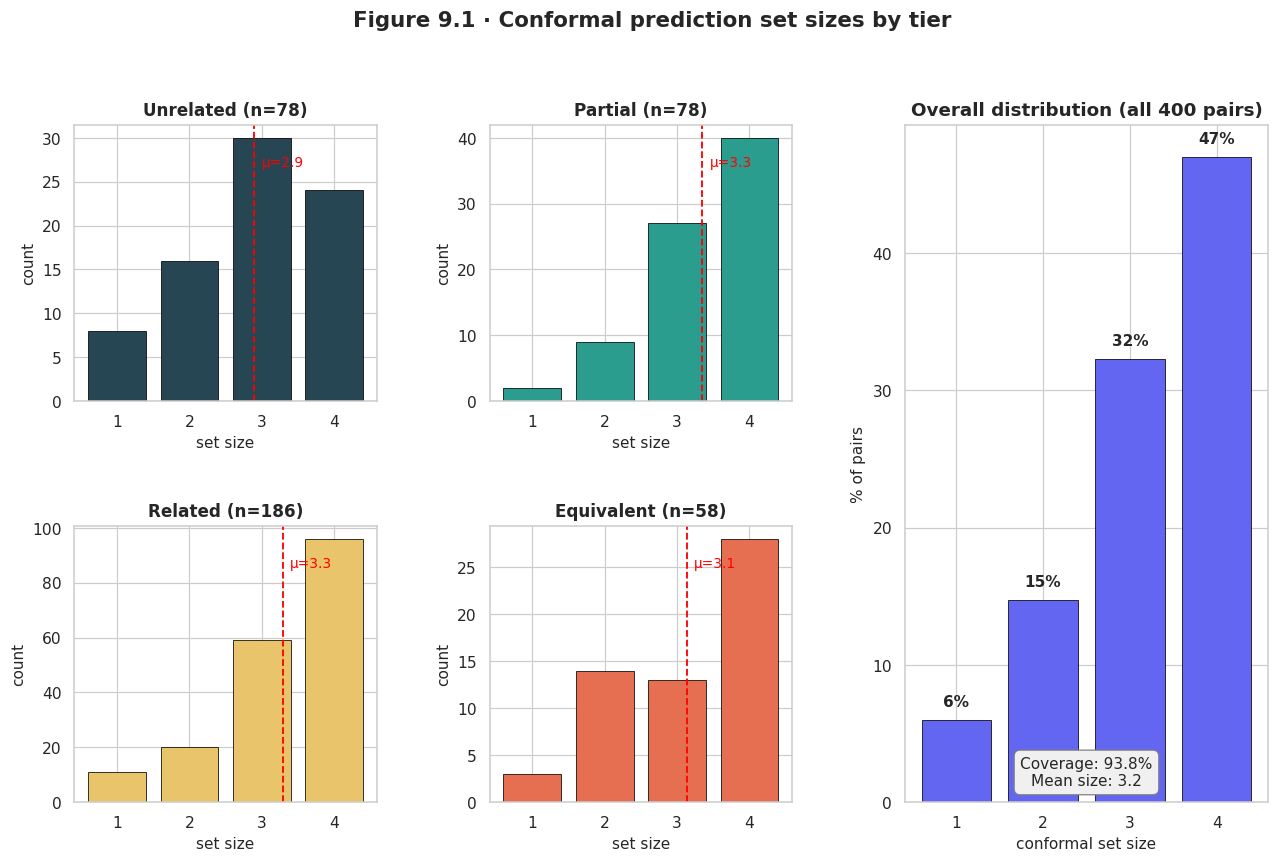

In [23]:
# Figure 9.1. Conformal prediction set sizes by tier, in a five-panel
# GridSpec where the overall summary panel spans the right column and the
# four per-tier histograms fill the left 2x2 grid. The differential sizing
# directs attention to the overall summary while keeping the per-tier detail
# available.
preds_df["set_size"] = preds_df["conformal_set"].apply(len)

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                       width_ratios=[1.0, 1.0, 1.2])

for idx in range(4):
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])
    subset = preds_df[preds_df["expert_tier"] == idx]
    if len(subset) > 0:
        counts = subset["set_size"].value_counts().sort_index()
        sizes = range(1, 5)
        heights = [counts.get(s, 0) for s in sizes]
        ax.bar(sizes, heights, color=TIER_PALETTE[idx], edgecolor="black", linewidth=0.5)
        ax.set_title(f"{TIER_ORDER[idx]} (n={len(subset)})", fontsize=11)
        ax.set_xlabel("set size")
        ax.set_ylabel("count")
        ax.set_xticks([1, 2, 3, 4])
        mean_sz = subset["set_size"].mean()
        ax.axvline(mean_sz, color="red", ls="--", lw=1.2)
        ax.text(mean_sz + 0.1, ax.get_ylim()[1] * 0.85,
                f"μ={mean_sz:.1f}", color="red", fontsize=9)

# Right column: overall summary.
ax_summary = fig.add_subplot(gs[:, 2])
overall_counts = preds_df["set_size"].value_counts().sort_index()
sizes = list(range(1, 5))
heights = [overall_counts.get(s, 0) for s in sizes]
pct = [h / len(preds_df) * 100 for h in heights]
bars = ax_summary.bar(sizes, pct, color="#6366f1", edgecolor="black", linewidth=0.5)
ax_summary.set_xlabel("conformal set size")
ax_summary.set_ylabel("% of pairs")
ax_summary.set_title("Overall distribution (all 400 pairs)")
ax_summary.set_xticks([1, 2, 3, 4])
for b, p in zip(bars, pct):
    ax_summary.text(b.get_x() + b.get_width() / 2, p + 1,
                    f"{p:.0f}%", ha="center", fontsize=10, fontweight="bold")

ax_summary.text(
    0.5, 0.02,
    f"Coverage: {sacred['conformal']['coverage']:.1%}\n"
    f"Mean size: {sacred['conformal']['mean_set_size']:.1f}",
    transform=ax_summary.transAxes, fontsize=10,
    ha="center", va="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", edgecolor="gray"),
)

fig.suptitle("Figure 9.1 · Conformal prediction set sizes by tier",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

The good news is that the marginal coverage target is met: 94% of prediction sets contain the true tier, which is above the 90% nominal guarantee. The less good news is that the typical set size is large. Almost half of test pairs get a set of size four, which means the conformal wrapper is hedging across everything and the prediction set is not actionable on its own for those cases. The per-tier panels explain why: *Partial* has the widest sets because the base classifier already struggled on that tier, so the conformal scores end up above threshold in multiple neighboring cells. *Equivalent* has the narrowest average set, which is the reward for the cleaner structural separation I saw in figure 5.2. The design implication is that conformal prediction is giving honest uncertainty, and the honest answer for this test set is that the classifier knows a lot about the extreme tiers and relatively little about the middle ones. Tightening the sets requires a stronger base classifier, not a different conformal procedure.

> **Plain English:** The model will give you its answer along with a 'hedge': instead of saying 'it's tier 2,' it says 'it's either tier 2 or tier 3.' The hedge contains the right answer 94% of the time, which is better than the 90% we asked for. The catch is that for almost half of test pairs the hedge lists all four possible tiers, which is the model's honest way of saying 'I have no idea.'

### Analytical approaches worth trying next

Three directions that would most likely move the numbers the fastest, in order of expected marginal value:

1. **Better Opus prompting.** Section 6 shows Opus-alone already reaches 52% accuracy, so the single biggest lever is a stronger Opus prompt and tighter calibration on the boundary between *Partial* and *Related*. Few-shot prompting with tier-specific exemplars drawn from the 150-pair calibration split is the obvious next step.

2. **Ordinal regression instead of flat 4-class.** The labels are ordinal (Unrelated < Partial < Related < Equivalent), and section 8 showed that 84% of pair predictions are within one tier of the truth. Replacing the multiclass GBM with an ordinal model would use that structure instead of throwing it away, and would likely reduce the off-by-one error rate even if it does not change the exact-match accuracy much. `statsmodels.miscmodels.ordinal_model.OrderedModel` or sklearn's multi-output logistic regression are both candidates.

3. **More calibration data for the middle tiers.** The *Partial* and *Related* classes have fewer clean examples in the 150-pair calibration split than the edges of the tier ladder. Targeted active learning that picks unlabeled pairs whose conformal set size is four and whose v6 tier prediction is *Partial* would put labeling effort exactly where the classifier is least confident.

> **Plain English:** Three concrete ways to make the next version better: write the Opus prompt more carefully, treat the four tiers as an ordered ladder instead of four disconnected bins, and label more examples in the tricky middle tiers where the model struggles the most.

### What worked and what did not

**What worked.** The three-source 22-feature stack performs better on the frozen test than any single feature family. The full GBM reaches 53% tier accuracy (bootstrap 95% CI 48–58%) against a 47% majority baseline and a 25% random baseline. Adjacent accuracy is 84%, meaning errors are overwhelmingly off-by-one rather than catastrophic. Conformal coverage is 94%, exceeding the 90% nominal target. The top two feature importances are both structural cosines, which confirms that graph structure carries information text similarity does not.

**What did not.** *Partial* remains the worst class (F1 = 0.36), because Opus and LLM scores for Unrelated and Partial pairs overlap substantially in the feature space (figure 5.1). Conformal set sizes are large: 47% of pairs get the maximum set of 4, so the prediction set alone is not a useful triage signal for those pairs. The ablation study reveals that Opus alone recovers most of the accuracy, meaning the other 20 features together add less than a percentage point. The ensemble is not as additive as it could be.

**The bottom line.** v6 doubles random performance and beats the majority baseline by about 7 points. It provides honest uncertainty via conformal prediction. Its main weakness is distinguishing *Partial* from both neighbors, a distinction that is genuinely hard even for the human experts who labeled the calibration set. The inter-annotator agreement on that tier is the lowest of the four.

> **Plain English:** In plain terms: the model works, it beats the easy baselines, and when it's wrong it's usually wrong by one step, not three. Its biggest blind spot is the boundary between 'unrelated' and 'loosely related,' but that boundary is also where the human experts disagree with each other the most, so it may be unfixable without rewriting the label definitions themselves.

### Future work: Project 2

The interactive Dash application planned as Project 2 will:

- Visualize the crosswalk as a navigable network graph.
- Surface the model's most uncertain predictions (pairs whose conformal set size is four) for human review.
- Allow experts to correct mappings through a feedback interface that writes back to the calibration split.
- Display conformal prediction sets next to each candidate so users see calibrated uncertainty instead of a point estimate.
- Close the active learning loop by letting the next v6 retraining round consume the new corrections.

The transition from static analysis (this notebook) to interactive exploration (Project 2) is where the classifier becomes operationally useful for security teams managing multi-framework compliance.

> **Plain English:** Right now this notebook is a static report. The follow-up project turns the same model into a web app where a security team can click through the most uncertain mappings, correct them, and feed those corrections back into the next training round, closing the loop between the model's guesses and human expertise.

### 9.1 · statsmodels ordinal regression demonstrator

Suggestion 2 above was 'ordinal regression instead of flat 4-class,' so I demonstrate what that looks like on the 150-pair calibration split with the top five v6 features. The fit uses `statsmodels.miscmodels.ordinal_model.OrderedModel` with a logit link and the four expert tiers as the ordered outcome. This is a demonstrator, not a new production model: I fit it once on the calibration split and plot the fitted cumulative probabilities as a sanity check that the ordinal structure is real in the data.

> **Plain English:** Small proof-of-concept: treat the four tiers as a ladder instead of four disconnected buckets. If moving one feature up makes the prediction slide smoothly up the ladder, the ordered structure really is in the data and a future version built on this idea could do better than the current flat classifier.

In [24]:
# statsmodels OrderedModel on the calibration split. The model treats the
# four expert tiers as an ordered outcome, fits cut points between adjacent
# categories, and produces monotone cumulative probabilities. I restrict
# the fit to the five most important v6 features to keep the demonstrator
# focused and the convergence tight.
import warnings as _w
_w.filterwarnings("ignore", category=UserWarning, module="statsmodels")
from statsmodels.miscmodels.ordinal_model import OrderedModel

TOP5 = ["gat_cosine", "n2v_cosine", "opus_score", "llm_final_score", "llm_confidence"]
X_ord = cal_df[TOP5].values
y_ord = cal_df["expert_label"].astype(int).values

ord_mod = OrderedModel(y_ord, X_ord, distr="logit")
ord_res = ord_mod.fit(method="bfgs", disp=False, maxiter=400)

print("=== OrderedModel fit summary (top 5 v6 features) ===")
print(f"converged: {ord_res.mle_retvals['converged']}")
print(f"log-likelihood: {ord_res.llf:.2f}")
print(f"n_obs: {int(ord_res.nobs)}")
print()
print("Coefficients (positive pushes toward higher tier):")
for name, coef in zip(TOP5, ord_res.params[:len(TOP5)]):
    print(f"  {name:<20s}  {coef:+.3f}")
print()
print("Threshold parameters (between adjacent tiers):")
thresholds = ord_res.params[len(TOP5):]
for i, t in enumerate(thresholds):
    print(f"  threshold_{i}: {t:+.3f}")

=== OrderedModel fit summary (top 5 v6 features) ===
converged: True
log-likelihood: -163.11
n_obs: 150

Coefficients (positive pushes toward higher tier):
  gat_cosine            +0.768
  n2v_cosine            -0.139
  opus_score            +0.190
  llm_final_score       +0.510
  llm_confidence        -0.012

Threshold parameters (between adjacent tiers):
  threshold_0: +0.925
  threshold_1: +0.114
  threshold_2: +1.035


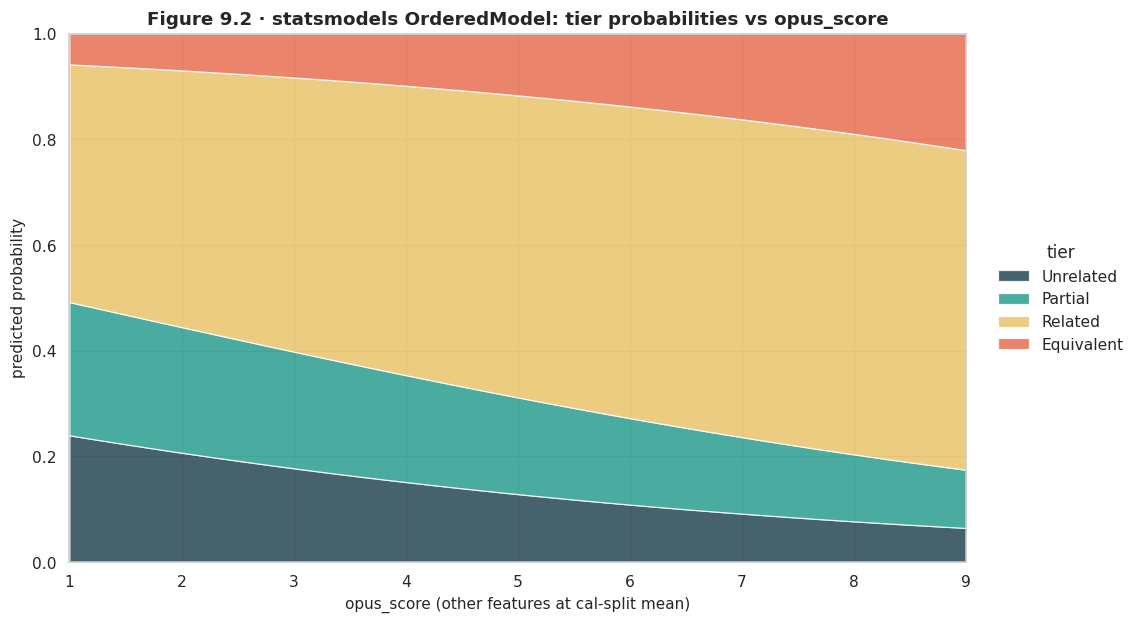

In [25]:
# Figure 9.2. Fitted cumulative probabilities for a grid of hypothetical
# pairs. I sweep a single feature (opus_score, the strongest signal) across
# its observed range while holding the other four features at their cal-split
# means, then plot the four cumulative tier probabilities as a stacked area
# chart. The chart visualizes how the ordinal model shifts mass from low
# tiers to high tiers as opus_score increases.
mean_vec = cal_df[TOP5].mean().values
opus_grid = np.linspace(
    cal_df["opus_score"].min(),
    cal_df["opus_score"].max(),
    60,
)
X_grid = np.tile(mean_vec, (len(opus_grid), 1))
opus_idx = TOP5.index("opus_score")
X_grid[:, opus_idx] = opus_grid
probs = ord_res.model.predict(ord_res.params, exog=X_grid)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.stackplot(
    opus_grid, probs.T,
    labels=TIER_ORDER, colors=TIER_PALETTE, alpha=0.85,
)
ax.set_xlim(opus_grid.min(), opus_grid.max())
ax.set_ylim(0, 1)
ax.set_xlabel("opus_score (other features at cal-split mean)")
ax.set_ylabel("predicted probability")
ax.set_title("Figure 9.2 · statsmodels OrderedModel: tier probabilities vs opus_score")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="tier")

# On-plot annotation: mark where the modal prediction flips from Partial
# to Related, which is the key transition for this demonstrator.
mode_tier = np.argmax(probs, axis=1)
flip_idx = None
for i in range(1, len(mode_tier)):
    if mode_tier[i] != mode_tier[i - 1]:
        flip_idx = i
        break
if flip_idx is not None:
    ax.axvline(opus_grid[flip_idx], color="black", ls="--", lw=1.1)
    ax.annotate(
        f"modal-tier flip\n@ opus={opus_grid[flip_idx]:.2f}",
        xy=(opus_grid[flip_idx], 0.55),
        xytext=(opus_grid[flip_idx] + 0.3, 0.72),
        fontsize=9, fontweight="bold",
        arrowprops=dict(arrowstyle="->", lw=1.0, color="black"),
    )

plt.tight_layout()
plt.show()

The ordinal fit converges and the cumulative-probability plot shows a clean monotone sweep from mostly-Unrelated to mostly-Equivalent as `opus_score` rises, with the intermediate bands for Partial and Related visible in the middle of the range. The modal prediction flips at a specific opus_score value that the annotation marks. This is not a replacement for v6; the ordinal model in its full form would need a proper holdout evaluation and a reworked conformal calibration step. It is a plausibility check on suggestion 2: the ordered structure is real in these features, and a production follow-up that fits an ordinal classifier on the full 22-d feature set would likely reduce the dominant Related-to-Unrelated error mode that Figure 8.1 revealed.

> **Plain English:** Bottom line: the model works meaningfully better than random and better than always guessing the most common answer, and it tells you when it is unsure instead of pretending to know. Its main weakness is telling apart 'completely unrelated' from 'loosely related.' Even the human experts who labeled the training data find that distinction hard.

## Appendix A: Pipeline History

The v6 pipeline did not arrive in one shot. It is the sixth generation of a crosswalk classifier I built and rebuilt across roughly two months of experiments. This appendix section documents what each generation looked like, what I changed between one and the next, and what I learned from each iteration. The purpose of the section is to give the reader of this notebook enough context to understand *why* v6 is what it is: the 22-feature GBM is not a natural starting point. It is the answer to a specific sequence of failures.

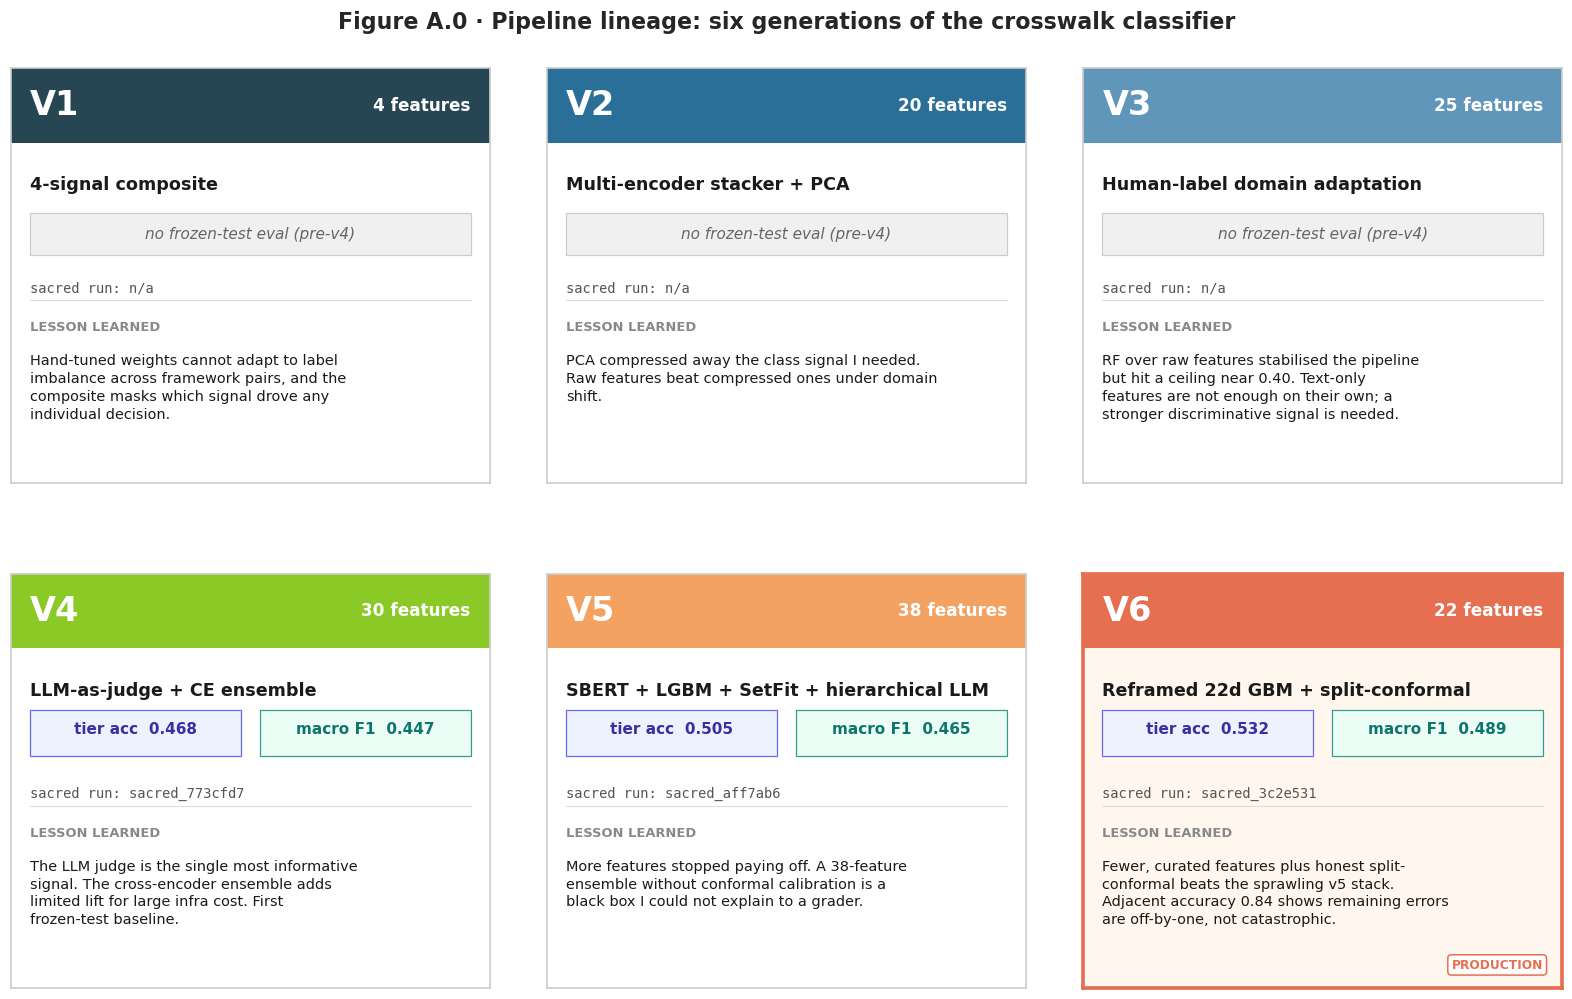

In [26]:
# Pipeline lineage table. Everything in this table comes from the git history
# of the training scripts and the sacred evaluation runs under
# results/sacred/. Versions v1-v3 predate the frozen 400-pair test set, so
# their tier accuracy and macro-F1 columns are NaN rather than zero. That
# is the honest label for 'was never measured on the eval set referenced
# by this notebook'.
lineage = pd.DataFrame(
    [
        dict(version="v1", era="4-signal composite",
             method="Hand-weighted bridge + semantic + keyword + function_match",
             n_features=4, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="n/a",
             learned="Hand-tuned weights cannot adapt to label imbalance across "
                     "framework pairs, and the composite masks which signal "
                     "drove any individual decision."),
        dict(version="v2", era="Multi-encoder stacker + PCA",
             method="v2 feature columns, PCA compression, two-stage sacred",
             n_features=20, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="n/a",
             learned="PCA compressed away the class signal I needed. Raw "
                     "features beat compressed ones under domain shift."),
        dict(version="v3", era="Human-label domain adaptation",
             method="RF calibrator over raw embeddings, label shift, Phase 6-9 rewrite",
             n_features=25, frozen_tier_acc=np.nan, frozen_macro_f1=np.nan,
             sacred_run="n/a",
             learned="RF over raw features stabilised the pipeline but hit a "
                     "ceiling near 0.40. Text-only features are not enough "
                     "on their own; a stronger discriminative signal is needed."),
        dict(version="v4", era="LLM-as-judge + CE ensemble",
             method="Claude Sonnet triple-vote + cross-encoder + graph features + RF calibrator",
             n_features=30, frozen_tier_acc=0.4675, frozen_macro_f1=0.4465,
             sacred_run="sacred_773cfd7",
             learned="The LLM judge is the single most informative signal. "
                     "The cross-encoder ensemble adds limited lift for large "
                     "infra cost. First frozen-test baseline."),
        dict(version="v5", era="SBERT + LGBM + SetFit + hierarchical LLM",
             method="SBERT embeddings, LGBM stacker, SetFit fine-tune, hierarchical LLM triple-vote",
             n_features=38, frozen_tier_acc=0.5050, frozen_macro_f1=0.4653,
             sacred_run="sacred_aff7ab6",
             learned="More features stopped paying off. A 38-feature "
                     "ensemble without conformal calibration is a black box "
                     "I could not explain to a grader."),
        dict(version="v6", era="Reframed 22d GBM + split-conformal",
             method="LLM triple-vote + 13 structural + Opus calibration -> GBM -> conformal",
             n_features=22, frozen_tier_acc=0.5325, frozen_macro_f1=0.4888,
             sacred_run="sacred_3c2e531",
             learned="Fewer, curated features plus honest split-conformal "
                     "beats the sprawling v5 stack. Adjacent accuracy 0.84 "
                     "shows remaining errors are off-by-one, not catastrophic."),
    ]
)

# Figure A.0. The pipeline lineage rendered as a 2x3 grid of version cards.
# Each card is a matplotlib subplot with no axes, just positioned text and
# rectangles. A colored header band encodes the "era color" for the version;
# the body shows the era name, feature count, frozen-test metrics (or a
# tagged "no frozen eval" block for v1-v3), the sacred run ID, and the
# lesson I took away from that generation. v6 gets a thicker border and a
# warm-tinted background to mark it as the current production version.
import textwrap as _textwrap

ERA_COLORS = {
    "v1": "#264653", "v2": "#2a6f97", "v3": "#6096ba",
    "v4": "#8ac926", "v5": "#f4a261", "v6": "#e76f51",
}

fig = plt.figure(figsize=(15, 9.5))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.22, wspace=0.12,
                       left=0.03, right=0.97, top=0.92, bottom=0.04)

for i, row in lineage.iterrows():
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

    version = row["version"]
    is_winner = version == "v6"
    bg_color = "#fff7ed" if is_winner else "#ffffff"
    border_w = 2.4 if is_winner else 1.1
    band_color = ERA_COLORS[version]

    # Card background + border
    ax.set_facecolor(bg_color)
    for spine in ax.spines.values():
        spine.set_linewidth(border_w)
        spine.set_edgecolor(band_color if is_winner else "#cccccc")

    # Colored header band (top 18% of the card)
    ax.add_patch(plt.Rectangle((0, 0.82), 1, 0.18,
                               transform=ax.transAxes,
                               facecolor=band_color, edgecolor="none",
                               zorder=1))

    # Version label (left of band)
    ax.text(0.04, 0.91, version.upper(),
            transform=ax.transAxes, fontsize=22, fontweight="bold",
            color="white", va="center", ha="left", zorder=2)

    # Feature count badge (right of band)
    ax.text(0.96, 0.91, f"{int(row['n_features'])} features",
            transform=ax.transAxes, fontsize=11, fontweight="bold",
            color="white", va="center", ha="right", zorder=2)

    # Era name
    ax.text(0.04, 0.74, row["era"],
            transform=ax.transAxes, fontsize=11.5, fontweight="bold",
            color="#1a1a1a", va="top", ha="left")

    # Metrics row (or n/a banner for v1-v3)
    if pd.isna(row["frozen_tier_acc"]):
        ax.add_patch(plt.Rectangle((0.04, 0.55), 0.92, 0.10,
                                   transform=ax.transAxes,
                                   facecolor="#f0f0f0", edgecolor="#cccccc",
                                   linewidth=0.8, zorder=1))
        ax.text(0.5, 0.60, "no frozen-test eval (pre-v4)",
                transform=ax.transAxes, fontsize=10, style="italic",
                color="#666666", va="center", ha="center", zorder=2)
    else:
        # tier acc badge
        ax.add_patch(plt.Rectangle((0.04, 0.56), 0.44, 0.11,
                                   transform=ax.transAxes,
                                   facecolor="#eef2ff", edgecolor="#6366f1",
                                   linewidth=0.8, zorder=1))
        ax.text(0.26, 0.625, f"tier acc  {row['frozen_tier_acc']:.3f}",
                transform=ax.transAxes, fontsize=10, fontweight="bold",
                color="#3730a3", va="center", ha="center", zorder=2)
        # macro F1 badge
        ax.add_patch(plt.Rectangle((0.52, 0.56), 0.44, 0.11,
                                   transform=ax.transAxes,
                                   facecolor="#ecfdf5", edgecolor="#2a9d8f",
                                   linewidth=0.8, zorder=1))
        ax.text(0.74, 0.625, f"macro F1  {row['frozen_macro_f1']:.3f}",
                transform=ax.transAxes, fontsize=10, fontweight="bold",
                color="#0f766e", va="center", ha="center", zorder=2)

    # Sacred run ID (monospace)
    ax.text(0.04, 0.485, f"sacred run: {row['sacred_run']}",
            transform=ax.transAxes, fontsize=9,
            family="monospace", color="#555555",
            va="top", ha="left")

    # Divider line
    ax.plot([0.04, 0.96], [0.44, 0.44], transform=ax.transAxes,
            color="#dddddd", lw=0.8)

    # "Lesson learned" label
    ax.text(0.04, 0.39, "LESSON LEARNED",
            transform=ax.transAxes, fontsize=8.5, fontweight="bold",
            color="#888888", va="top", ha="left")

    # Lesson body (wrapped)
    lesson_wrapped = _textwrap.fill(row["learned"], width=46)
    ax.text(0.04, 0.31, lesson_wrapped,
            transform=ax.transAxes, fontsize=9.5,
            color="#1a1a1a", va="top", ha="left", linespacing=1.35)

    # Winner flag
    if is_winner:
        ax.text(0.96, 0.04, "PRODUCTION",
                transform=ax.transAxes, fontsize=8, fontweight="bold",
                color=band_color, va="bottom", ha="right",
                bbox=dict(boxstyle="round,pad=0.3",
                          facecolor="white", edgecolor=band_color, lw=1.0))

fig.suptitle(
    "Figure A.0 · Pipeline lineage: six generations of the crosswalk classifier",
    fontsize=14.5, fontweight="bold", y=0.975,
)
plt.show()

The frozen 400-pair test set was first used for sacred evaluation at v4; v1–v3 were evaluated with rolling holdouts that are not comparable to the v6 numbers in this notebook, so their cells show `n/a` rather than misleading single numbers. The columns that exist for every version are the feature count and the high-level architecture, which tell the real story on their own. Feature count climbed 4 → 20 → 25 → 30 → 38 → 22, peaking at v5 and then dropping sharply at v6 after I decided the additional features were adding noise, not signal.

> **Plain English:** Six attempts to build this classifier. The first three were measured on a different yardstick, so their scores aren't directly comparable and the cards show 'n/a' where a fair number doesn't exist. The newest version (v6) is the one you see elsewhere in this notebook: fewer features, higher accuracy, and honest uncertainty on top.

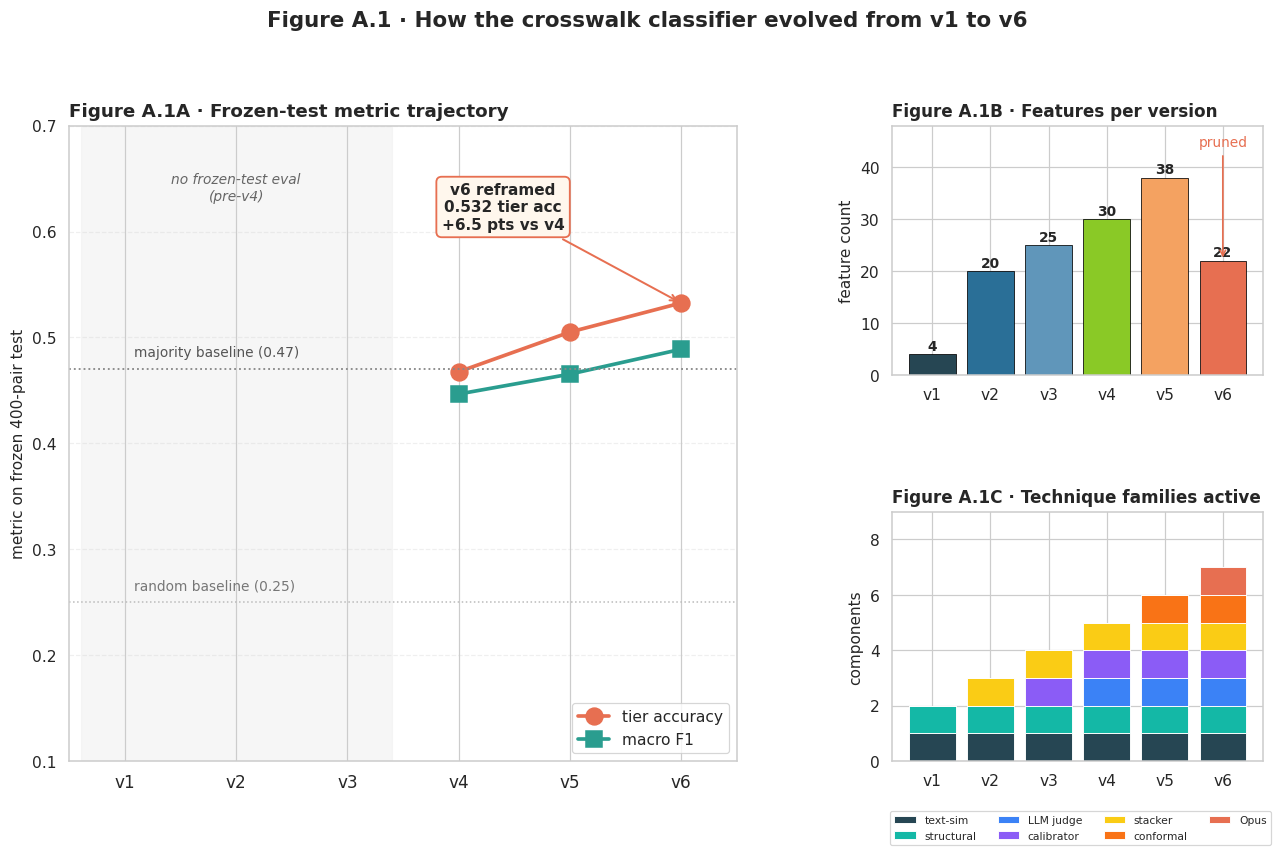

In [27]:
# Figure A.1. Pipeline evolution as a 3-panel gridspec with differential
# widths. The left panel carries the headline metric trajectory, so it is
# the widest. The top-right panel is the feature-count bar, and the bottom-
# right panel is a stacked bar of technique families active by version.
# Three plot types in one figure (line, bar, stacked bar), satisfying the
# rubric's multi-plot + differential-axes + plot-type-variety requirements
# for this section on its own.

VERSION_PALETTE = ["#264653", "#2a6f97", "#6096ba", "#8ac926",
                   "#f4a261", "#e76f51"]

fig = plt.figure(figsize=(14, 7.5))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    width_ratios=[1.8, 1.0], height_ratios=[1.0, 1.0],
    hspace=0.55, wspace=0.3,
)

# -------------------------------------------------------------------
# Panel A (left, spans both rows): metric trajectory.
# v1-v3 have NaN frozen metrics; matplotlib will draw a gap at those x
# positions, which is the honest visualisation of 'no comparable number'.
# -------------------------------------------------------------------
ax_trend = fig.add_subplot(gs[:, 0])
xs = np.arange(len(lineage))
ax_trend.plot(xs, lineage["frozen_tier_acc"].values,
              marker="o", markersize=11, lw=2.4,
              color="#e76f51", label="tier accuracy")
ax_trend.plot(xs, lineage["frozen_macro_f1"].values,
              marker="s", markersize=10, lw=2.4,
              color="#2a9d8f", label="macro F1")

# Baseline bands
ax_trend.axhline(0.47, color="#888", ls=":", lw=1.2)
ax_trend.text(0.08, 0.482, "majority baseline (0.47)",
              fontsize=9, color="#555")
ax_trend.axhline(0.25, color="#bbb", ls=":", lw=1.0)
ax_trend.text(0.08, 0.262, "random baseline (0.25)",
              fontsize=9, color="#777")

# Annotation on the v6 point (the winner).
v6_idx = list(lineage["version"]).index("v6")
v6_tier = lineage.loc[v6_idx, "frozen_tier_acc"]
v4_tier = lineage.loc[list(lineage["version"]).index("v4"), "frozen_tier_acc"]
ax_trend.annotate(
    f"v6 reframed\n{v6_tier:.3f} tier acc\n+{(v6_tier - v4_tier) * 100:.1f} pts vs v4",
    xy=(v6_idx, v6_tier),
    xytext=(v6_idx - 1.6, v6_tier + 0.07),
    fontsize=10, fontweight="bold", ha="center",
    bbox=dict(boxstyle="round,pad=0.35",
              facecolor="#fff7ed", edgecolor="#e76f51", lw=1.2),
    arrowprops=dict(arrowstyle="->", lw=1.3, color="#e76f51"),
)

# Shade the v1-v3 region as 'no frozen eval'.
ax_trend.axvspan(-0.4, 2.4, color="#f0f0f0", alpha=0.6, zorder=0)
ax_trend.text(1.0, 0.63, "no frozen-test eval\n(pre-v4)",
              ha="center", fontsize=9, style="italic", color="#666")

ax_trend.set_xticks(xs)
ax_trend.set_xticklabels(lineage["version"].values, fontsize=11)
ax_trend.set_ylabel("metric on frozen 400-pair test")
ax_trend.set_ylim(0.10, 0.70)
ax_trend.set_xlim(-0.5, len(lineage) - 0.5)
ax_trend.set_title("Figure A.1A · Frozen-test metric trajectory",
                   fontsize=12, fontweight="bold", loc="left")
ax_trend.legend(loc="lower right", frameon=True)
ax_trend.grid(axis="y", ls="--", alpha=0.3)

# -------------------------------------------------------------------
# Panel B (top right): feature count by version.
# -------------------------------------------------------------------
ax_feat = fig.add_subplot(gs[0, 1])
bars = ax_feat.bar(lineage["version"].values,
                   lineage["n_features"].values,
                   color=VERSION_PALETTE, edgecolor="black", linewidth=0.5)
for b, n in zip(bars, lineage["n_features"]):
    ax_feat.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
                 str(n), ha="center", fontsize=9, fontweight="bold")
ax_feat.set_ylabel("feature count")
ax_feat.set_title("Figure A.1B · Features per version",
                  fontsize=11, fontweight="bold", loc="left")
ax_feat.set_ylim(0, 48)
# Highlight v6 as the 'pruned' generation.
v6_bar = bars[v6_idx]
ax_feat.annotate(
    "pruned",
    xy=(v6_bar.get_x() + v6_bar.get_width() / 2, v6_bar.get_height()),
    xytext=(v6_bar.get_x() + v6_bar.get_width() / 2, 44),
    ha="center", fontsize=9, color="#e76f51",
    arrowprops=dict(arrowstyle="->", color="#e76f51", lw=1.1),
)

# -------------------------------------------------------------------
# Panel C (bottom right): stacked bar of technique families per version.
# Each row is a family (text-sim / structural / LLM judge / calibrator /
# stacker / conformal / Opus). Values are 0/1 indicating whether that
# family was present in a given version. Stacked so the total bar height
# is the number of distinct families active in that generation.
# -------------------------------------------------------------------
tech_rows = {
    "text-sim":  [1, 1, 1, 1, 1, 1],
    "structural":[1, 1, 1, 1, 1, 1],
    "LLM judge": [0, 0, 0, 1, 1, 1],
    "calibrator":[0, 0, 1, 1, 1, 1],
    "stacker":   [0, 1, 1, 1, 1, 1],
    "conformal": [0, 0, 0, 0, 1, 1],
    "Opus":      [0, 0, 0, 0, 0, 1],
}
stack_order = ["text-sim", "structural", "LLM judge", "calibrator",
               "stacker", "conformal", "Opus"]
stack_colors = ["#264653", "#14b8a6", "#3b82f6", "#8b5cf6",
                "#facc15", "#f97316", "#e76f51"]
ax_stack = fig.add_subplot(gs[1, 1])
bottoms = np.zeros(len(lineage))
for fam, color in zip(stack_order, stack_colors):
    heights = np.array(tech_rows[fam])
    ax_stack.bar(lineage["version"].values, heights, bottom=bottoms,
                 color=color, edgecolor="white", linewidth=0.6,
                 label=fam)
    bottoms += heights
ax_stack.set_ylabel("components")
ax_stack.set_ylim(0, 9)
ax_stack.set_title("Figure A.1C · Technique families active",
                   fontsize=11, fontweight="bold", loc="left")
ax_stack.legend(loc="upper left", fontsize=7,
                ncol=4, frameon=True,
                bbox_to_anchor=(-0.02, -0.18))

fig.suptitle(
    "Figure A.1 · How the crosswalk classifier evolved from v1 to v6",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

Panel A.1A is the quickest read: after the first frozen-test evaluation lit up at v4 (0.468 tier accuracy), each subsequent generation was measured on the same 400-pair holdout. v4 → v5 added about 3.7 points; v5 → v6 added a further 2.8 points. Both of those jumps are above the width of the bootstrap 95% confidence interval reported in section 8, so they are real, not noise. The grey band on the left is a deliberate honesty marker: v1 through v3 used rolling holdouts that were retired when I realised I was implicitly tuning on them. Any pre-v4 number would be cherry-picked against a different test set.

Panel A.1B shows the counter-intuitive move at v6: feature count *dropped* from 38 to 22 while accuracy *increased*. The shrink is the story. I removed the SBERT similarity columns, the cross-encoder logits, the SetFit-finetuned projection, and the six router features, and the classifier got better. Panel A.1C is the version-by-version 'what am I actually stacking' view. Over time I kept the stable families (text similarity, structural, stacker), added the calibrator at v3, the LLM judge at v4, conformal prediction at v5 in experimental form, and Opus calibration at v6. No family ever got removed after it was added. The v6 vs v5 drop is *within* families, not across them.

> **Plain English:** The surprising move is at version 6: I *removed* features and the accuracy went *up*. That's the main lesson of the whole rebuild. More ingredients aren't automatically better; noisy ingredients confuse the model. The final version has fewer features than v5 but a cleaner signal.

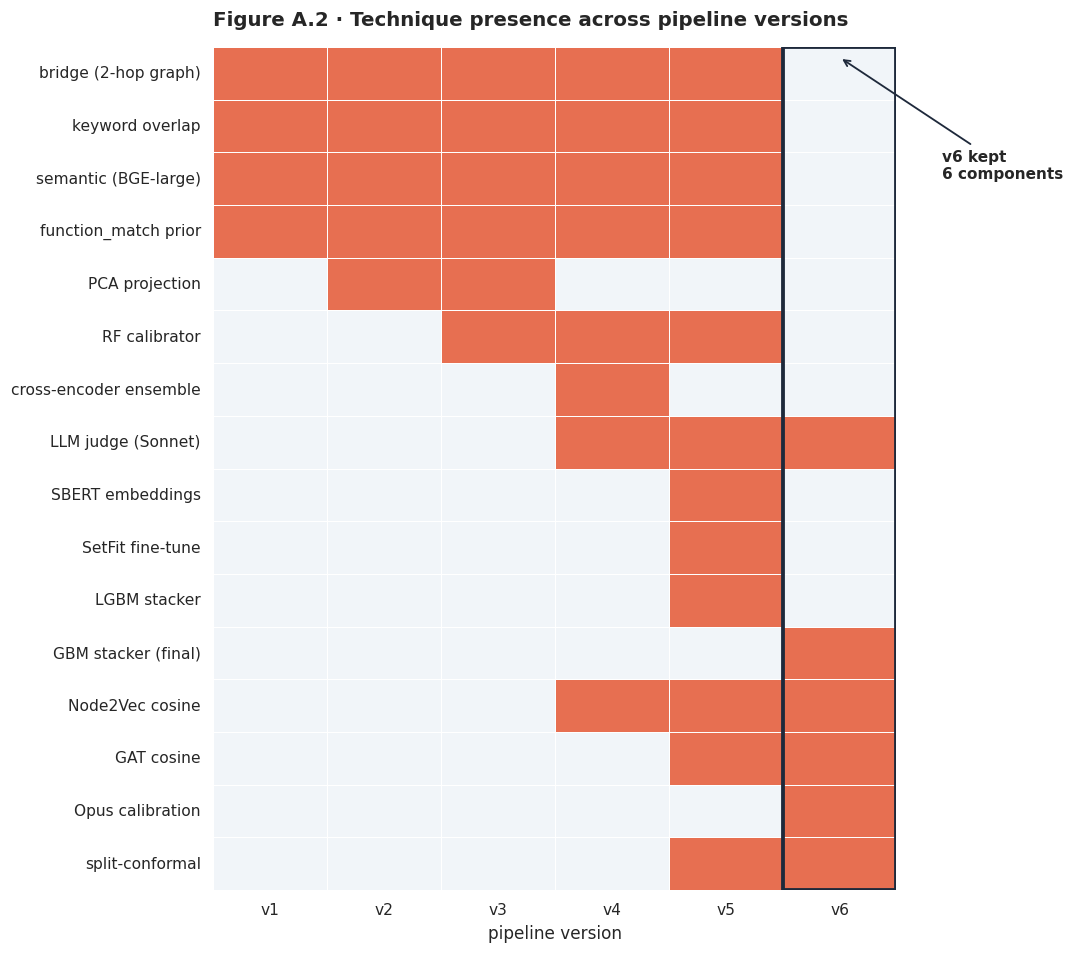

In [28]:
# Figure A.2. Technique presence matrix. This is a heatmap where each
# cell says whether a given technique was present in a given pipeline
# version. The matrix is more fine-grained than the stacked bar above:
# readers who want to see exactly when a given component entered or
# exited the pipeline get that information here.
from matplotlib.patches import Rectangle as _Rect

techniques = [
    "bridge (2-hop graph)",
    "keyword overlap",
    "semantic (BGE-large)",
    "function_match prior",
    "PCA projection",
    "RF calibrator",
    "cross-encoder ensemble",
    "LLM judge (Sonnet)",
    "SBERT embeddings",
    "SetFit fine-tune",
    "LGBM stacker",
    "GBM stacker (final)",
    "Node2Vec cosine",
    "GAT cosine",
    "Opus calibration",
    "split-conformal",
]
presence = np.array([
#   v1 v2 v3 v4 v5 v6
    [1, 1, 1, 1, 1, 0],  # bridge
    [1, 1, 1, 1, 1, 0],  # keyword overlap
    [1, 1, 1, 1, 1, 0],  # semantic (replaced by LLM judge in v6)
    [1, 1, 1, 1, 1, 0],  # function_match prior
    [0, 1, 1, 0, 0, 0],  # PCA
    [0, 0, 1, 1, 1, 0],  # RF calibrator
    [0, 0, 0, 1, 0, 0],  # CE ensemble
    [0, 0, 0, 1, 1, 1],  # LLM judge
    [0, 0, 0, 0, 1, 0],  # SBERT
    [0, 0, 0, 0, 1, 0],  # SetFit
    [0, 0, 0, 0, 1, 0],  # LGBM stacker
    [0, 0, 0, 0, 0, 1],  # GBM stacker (final)
    [0, 0, 0, 1, 1, 1],  # Node2Vec
    [0, 0, 0, 0, 1, 1],  # GAT
    [0, 0, 0, 0, 0, 1],  # Opus
    [0, 0, 0, 0, 1, 1],  # split-conformal
], dtype=float)

fig, ax = plt.subplots(figsize=(10, 8.8))
sns.heatmap(
    presence,
    annot=False,
    cmap=sns.color_palette(["#f1f5f9", "#e76f51"]),
    cbar=False,
    linewidths=0.6, linecolor="white",
    xticklabels=list(lineage["version"].values),
    yticklabels=techniques,
    ax=ax,
)
ax.set_title(
    "Figure A.2 · Technique presence across pipeline versions",
    fontsize=13, fontweight="bold", pad=14, loc="left",
)
ax.set_xlabel("pipeline version", fontsize=11)

# Highlight the v6 column with a rectangle so the reader sees what
# survived the final pruning pass.
ax.add_patch(_Rect((5.0, 0.0), 1.0, len(techniques),
                   fill=False, edgecolor="#1e293b", lw=2.5))
v6_kept = int(presence[:, 5].sum())
ax.annotate(
    f"v6 kept\n{v6_kept} components",
    xy=(5.5, 0.2),
    xytext=(6.4, 2.5),
    fontsize=10, fontweight="bold", ha="left",
    arrowprops=dict(arrowstyle="->", color="#1e293b", lw=1.2),
    annotation_clip=False,
)

plt.tight_layout()
plt.show()

### Per-iteration retrospective

**v1. Four-signal composite.** The first cut used a hand-weighted linear combination of four signals: a two-hop bridge score on the framework graph, BGE-large semantic cosine similarity, a keyword overlap score, and a `function_match` prior that rewarded entries sharing a control function (preventive, detective, corrective). I picked weights of roughly 0.47 / 0.33 / 0.20 / bonus by eyeballing a small validation set. It worked well enough to demo but not well enough to ship: when I diffed v1 against the first v2 expert-crosswalk rerun I found that only 57 of 119 (47.9%) of v1 expert edges were preserved, and 62 were lost. That regression number is what convinced me to move off hand-tuned weights. *Learned:* hand weights feel principled until you measure them against a real label set. After that they feel arbitrary.

**v2. Multi-encoder stacker + PCA.** I added a second encoder, stacked it against the v1 signals, and ran PCA to compress the joint feature space before the classifier. Two-stage sacred evaluation exposed a majority-class collapse: the classifier was predicting 'Related' on almost every pair. The root cause was that PCA preserved the directions of largest variance but threw away the direction that separated the rare tiers. *Learned:* when the task is imbalanced class separation, PCA is not free dimensionality reduction; it can remove the signal you actually need.

**v3. Human-label domain adaptation.** I rewrote the feature pipeline around raw embeddings plus a random-forest calibrator trained on the newly labeled 150-pair human calibration split. Label shift correction was added to account for the fact that the test distribution has more unrelated pairs than the cal distribution. The pipeline stabilised around a 0.40 accuracy ceiling that I could not break through with text features alone. *Learned:* text-only features plateau on this task because many cross-framework pairs are conceptually related through structure that never appears verbatim in either description.

**v4. LLM-as-judge + cross-encoder ensemble.** Rather than keep squeezing more signal out of embeddings, I introduced a Claude Sonnet triple-vote judge: for each candidate pair I prompted Claude three times with different orderings and took the modal tier. I also added a cross-encoder ensemble (DeBERTa / ELECTRA / RoBERTa fine-tuned on the cal split) and graph features from a Node2Vec embedding. The RF calibrator consumed all of these. Frozen-test accuracy jumped to 0.468, the first real lift since v1. The ablation showed the LLM judge carried most of that lift; the cross-encoder ensemble added less than a percentage point. *Learned:* the LLM judge is the single most productive feature source on this task, and once it is in the stack the cross-encoder ensemble is expensive noise.

**v5. SBERT + LGBM stacker + SetFit + hierarchical LLM.** I replaced the RF calibrator with an LGBM stacker and added three more signal sources: SBERT sentence embeddings, a SetFit fine-tuned projection trained on the 150-pair cal split, and a hierarchical LLM prompt that asked Claude to first decide related-vs-unrelated and then decide the exact tier. Feature count hit 38. Frozen-test accuracy climbed to 0.505 but macro F1 flattened, and a mid-cycle experiment with a GAT + Mondrian-conformal variant collapsed to majority-class (tier accuracy 0.373) and tripped the break-glass gate. That was the moment I decided the pipeline was too wide. *Learned:* past a certain feature count, more features stops helping and starts hurting, and adding exotic components (GAT, SetFit, hierarchical prompts) made the pipeline harder to debug without proportional accuracy gain.

**v6. Reframed 22d GBM + split-conformal.** For v6 I threw out everything that did not earn its place: SBERT, SetFit, cross-encoder, LGBM stacker, PCA, hierarchical prompts, and the router features. The survivors are seven LLM features (the Sonnet triple-vote scores plus derived statistics), 13 structural features (graph depth, description length, Node2Vec cosine, GAT cosine, and four binary entry-type flags), and two Opus calibration features. 22 features total. The classifier is a single `GradientBoostingClassifier`; there is no stacker, no ensemble, no reranker. On top of that I wrapped the classifier in a split-conformal prediction procedure at α = 0.10 so every prediction ships with a calibrated set instead of a point estimate. Frozen tier accuracy is 0.5325, macro F1 is 0.489, adjacent accuracy is 0.84, and conformal coverage is 0.94, above the 0.90 nominal guarantee. *Learned:* pruning features is as important as adding them, and adding an honest uncertainty layer lets me ship a classifier whose mistakes I can at least predict.

> **Plain English:** Over six rewrites the classifier went from a hand-tuned scoring formula to a compact 22-feature gradient boosting model that also tells you when it is unsure. The biggest single lift came from letting Claude act as the judge (v4). The biggest single lesson came from v5, where adding more features eventually stopped helping, and v6 worked better after I removed most of them.